# Final Course Project: Survival Prediction and Model Comparison

Oded Katz — 211862693 &nbsp;&nbsp;|&nbsp;&nbsp; Diana Morgan — 336472261


| Notebook section | Assignment item |
|---|---|
| 0. Setup and preprocessing | shared data preparation |
| 1. Recap of Project Assignment 1 | item 1 |
| 2. Recap of Project Assignment 2 | item 2 |
| 3. Research questions | item 3 |
| 4. Train-test split | item 4 |
| 5. Refitting the selected Cox model | item 5 |
| 6. One-year survival prediction (Cox) | item 6 |
| 7. Additional survival models (RSF, DeepSurv, Cox-Time) | item 7 |
| 8. Comparison of one-year prediction curves | item 8 |
| 9. Test-set model comparison | item 9 |
| 10. Additional analyses | item 10 |
| 11. Final discussion | item 11 |

---
## 0. Setup and preprocessing

We start from the dataset PA1 produced, with missing continuous values filled in by their medians; no categorical covariate had missing values. Two variables from PA2 are rebuilt here:

* `cat_comorbidities` — the count of the nine comorbidity indicators, grouped into 0-1 (reference), 2-3 and 4+.
* `delta_BUN` — `BUN_discharge` minus `BUN_admission`, the change in blood urea nitrogen during the stay.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter

# ---- global configuration -------------------------------------------------
SEED = 42                      
np.random.seed(SEED)

DATA_PATH = os.path.join("..", "PA1", "imputed_data.csv")
FIG_DIR = "figures"
TAB_DIR = "tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

TIME_COL = "time_discharge_to_death_MONTHS"
EVENT_COL = "death"
HORIZON = 12.0                 
MAX_FOLLOWUP = 36.0           

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

In [2]:
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=[c for c in ["survival_status"] if c in df.columns])

# ---- comorbidity burden (PA2) ---------------------------------------------
COMORBIDITY_COLS = ["diabetes", "hypertension", "COPD", "PVD",
                    "CKD", "IHD", "AF", "VHD", "PHTN"]

df["n_comorbidities"] = df[COMORBIDITY_COLS].sum(axis=1)
df["cat_comorbidities"] = pd.cut(
    df["n_comorbidities"],
    bins=[0, 1, 3, np.inf],
    include_lowest=True,
    labels=["0-1", "2-3", "4+"],
)

# ---- change in BUN during hospitalisation (PA2) ---------------------------
df["delta_BUN"] = df["BUN_discharge"] - df["BUN_admission"]

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Any remaining missing values: {bool(df.isna().any().any())}")
df.head()

Rows: 3961   Columns: 30
Any remaining missing values: False


,gender_0male_1female,age_YEARS,diabetes,hypertension,COPD,PVD,CKD,IHD,AF,VHD,PHTN,BNP,BUN_admission,BUN_discharge,creatinine_admission,creatinine_discharge,GFR_admission,GFR_discharge,WBC,sodium,RDW,platelets,bilirubin,potassium,length_of_stay_DAYS,time_discharge_to_death_MONTHS,death,n_comorbidities,cat_comorbidities,delta_BUN
0,0,48.85803,0,0,0,0,0,0,0,0,0,1258.04,66.0,65.0,1.10,1.10,78.960885,80.768963,9.40,138.00,21.3,178.0,1.090,3.9,0.456785,5.000000,1,0,0-1,-1.0
1,0,49.67481,0,0,0,0,0,0,0,0,0,291.55,46.0,46.0,1.53,1.56,55.584022,54.435869,4.40,127.42,21.6,114.0,5.765,4.8,0.245513,0.700000,1,0,0-1,0.0
2,0,85.35892,0,0,0,0,0,0,0,0,0,1473.78,16.0,17.0,1.43,1.27,41.135539,48.993978,10.50,130.00,17.2,289.0,0.520,4.0,1.632458,8.033333,1,0,0-1,1.0
3,0,52.80388,0,0,0,0,0,0,0,0,0,940.32,28.3,30.0,1.43,1.13,55.718423,75.232868,8.50,135.00,13.3,188.0,0.550,6.1,5.921769,0.033333,1,0,0-1,1.7
4,0,67.30150,0,0,0,0,0,0,0,0,0,2625.98,59.0,28.0,2.65,2.32,26.914463,31.042884,13.17,136.40,14.7,274.0,0.500,5.3,17.214475,20.433333,0,0,0-1,-31.0


---
# 1. Brief recap of Project Assignment 1

PA1 was the exploratory analysis: characterising the covariates, handling missing values, defining the survival outcome and censoring mechanism, and examining the Kaplan-Meier curves that motivated our research questions.


## 1.1 Dataset and survival outcome

Synthetic dataset 2. Each row is a patient admitted with acute decompensated heart failure who left hospital alive, described by 25 covariates, a survival time and an event indicator.

* **Event.** Death from any cause, `death = 1`.
* **Survival time.** `time_discharge_to_death_MONTHS`, from discharge to death or to the end of follow-up.
* **Censoring.** Follow-up ends at 36 months and patients with `death = 0` are right-censored, about two thirds of them at that cutoff and the rest spread fairly evenly over the observation period. We assume censoring is independent of survival time given the covariates.


## 1.2 Sample size, events and censoring

In [3]:
n_total = len(df)
n_events = int((df[EVENT_COL] == 1).sum())
n_censored = int((df[EVENT_COL] == 0).sum())

followup = df[TIME_COL]
is_censored = df[EVENT_COL] == 0

censored_at_end = int((is_censored & (followup >= MAX_FOLLOWUP)).sum())
censored_early = int((is_censored & (followup < MAX_FOLLOWUP)).sum())
early_times = followup[is_censored & (followup < MAX_FOLLOWUP)]

sample_summary = pd.DataFrame(
    {
        "n": [n_total, n_events, n_censored, censored_at_end, censored_early],
        "% of cohort": [
            100.0,
            100 * n_events / n_total,
            100 * n_censored / n_total,
            100 * censored_at_end / n_total,
            100 * censored_early / n_total,
        ],
    },
    index=[
        "Patients (sample size)",
        "Observed deaths (death = 1)",
        "Censored observations (death = 0)",
        "  of which administratively censored at 36 months",
        "  of which lost to follow-up before 36 months",
    ],
).round(2)

n_events_by_horizon = int(((df[EVENT_COL] == 1) & (followup <= HORIZON)).sum())
n_censored_pre_horizon = int((is_censored & (followup < HORIZON)).sum())

print("Follow-up time (months): "
      f"median = {followup.median():.2f}, "
      f"IQR = [{followup.quantile(.25):.2f}, {followup.quantile(.75):.2f}], "
      f"range = [{followup.min():.2f}, {followup.max():.2f}]")
print(f"Total person-months of follow-up: {followup.sum():,.0f}")
print(f"Censoring times of the {censored_early} lost to follow-up before {MAX_FOLLOWUP:.0f} months: "
      f"median = {early_times.median():.2f}, "
      f"IQR = [{early_times.quantile(.25):.2f}, {early_times.quantile(.75):.2f}]")
print(f"By the {HORIZON:.0f}-month horizon: {n_events_by_horizon} deaths, "
      f"{n_censored_pre_horizon} censored beforehand")
sample_summary

Follow-up time (months): median = 25.60, IQR = [8.83, 36.00], range = [0.00, 36.00]
Total person-months of follow-up: 88,266
Censoring times of the 809 lost to follow-up before 36 months: median = 16.47, IQR = [7.93, 25.37]
By the 12-month horizon: 947 deaths, 328 censored beforehand


,n,% of cohort
Patients (sample size),3961,100.00
Observed deaths (death = 1),1679,42.39
Censored observations (death = 0),2282,57.61
of which administratively censored at 36 months,1473,37.19
of which lost to follow-up before 36 months,809,20.42


In [4]:
sample_summary.to_csv(os.path.join(TAB_DIR, "table1a_sample_size.csv"))

**Table 1a**. Of 3,961 patients, 1,679 (42.4%) died during follow-up. Most of the 2,282 censored patients reach the 36-month cutoff; 809 drop out earlier, at a median of 16.5 months. Median follow-up is 25.6 months.


## 1.3 Covariates

The covariates fall into five blocks: demographics, the comorbidity indicators, admission labs, discharge labs and length of stay. Table 1 summarises them, continuous variables as median [Q1, Q3] and binary ones as n (%).


In [5]:
LABELS = {
    "gender_0male_1female": "Female sex",
    "age_YEARS": "Age (years)",
    "diabetes": "Diabetes",
    "hypertension": "Hypertension",
    "COPD": "COPD",
    "PVD": "Peripheral vascular disease",
    "CKD": "Chronic kidney disease",
    "IHD": "Ischaemic heart disease",
    "AF": "Atrial fibrillation",
    "VHD": "Valvular heart disease",
    "PHTN": "Pulmonary hypertension",
    "BNP": "BNP, admission (pg/mL)",
    "BUN_admission": "BUN, admission (mg/dL)",
    "creatinine_admission": "Creatinine, admission (mg/dL)",
    "GFR_admission": "GFR, admission (mL/min/1.73m2)",
    "BUN_discharge": "BUN, discharge (mg/dL)",
    "creatinine_discharge": "Creatinine, discharge (mg/dL)",
    "GFR_discharge": "GFR, discharge (mL/min/1.73m2)",
    "WBC": "White blood cells (1000/uL)",
    "sodium": "Sodium (mEq/L)",
    "RDW": "Red cell distribution width (%)",
    "platelets": "Platelets (1000/uL)",
    "bilirubin": "Bilirubin (mg/dL)",
    "potassium": "Potassium (mEq/L)",
    "length_of_stay_DAYS": "Length of stay (days)",
}

BLOCKS = [
    ("Demographics", ["age_YEARS", "gender_0male_1female"]),
    ("Comorbidities (as recorded in PA1)", COMORBIDITY_COLS),
    ("Laboratory values on admission",
     ["BNP", "BUN_admission", "creatinine_admission", "GFR_admission"]),
    ("Laboratory values on discharge",
     ["BUN_discharge", "creatinine_discharge", "GFR_discharge"]),
    ("Other laboratory values",
     ["WBC", "sodium", "RDW", "platelets", "bilirubin", "potassium"]),
    ("Hospitalisation", ["length_of_stay_DAYS"]),
]

BINARY_COLS = ["gender_0male_1female"] + COMORBIDITY_COLS


def _continuous(series):
    return f"{series.median():.2f} [{series.quantile(.25):.2f}, {series.quantile(.75):.2f}]"


def _count(mask, n):
    k = int(mask.sum())
    return f"{k} ({100 * k / n:.1f}%)"


def build_covariate_table(data):
    n = len(data)
    rows = []
    for block, cols in BLOCKS:
        rows.append([f"[{block}]", "", ""])
        for col in cols:
            label = LABELS.get(col, col)
            if col in BINARY_COLS:
                rows.append([label, "n (%)", _count(data[col] == 1, n)])
            elif str(data[col].dtype) == "category":
                rows.append([label, "n (%)", ""])
                for level in data[col].cat.categories:
                    rows.append([f"    {level}", "", _count(data[col] == level, n)])
            else:
                rows.append([label, "median [Q1, Q3]", _continuous(data[col])])
    return pd.DataFrame(rows, columns=["Covariate", "Summary", f"All patients (n = {n})"])


table_one = build_covariate_table(df)
table_one.to_csv(os.path.join(TAB_DIR, "table1_covariates.csv"), index=False)
table_one.style.hide(axis="index")

Covariate,Summary,All patients (n = 3961)
[Demographics],,
Age (years),"median [Q1, Q3]","76.18 [66.85, 83.24]"
Female sex,n (%),1842 (46.5%)
[Comorbidities (as recorded in PA1)],,
Diabetes,n (%),2147 (54.2%)
Hypertension,n (%),3432 (86.6%)
COPD,n (%),405 (10.2%)
Peripheral vascular disease,n (%),367 (9.3%)
Chronic kidney disease,n (%),805 (20.3%)
Ischaemic heart disease,n (%),2484 (62.7%)


**Table 1**. Median age is 76 and 46.5% are women. Comorbidities are common and overlapping, hypertension in 87% of patients and ischaemic heart disease in 63%. Median BUN rises from 25 mg/dL on admission to 28 at discharge, and the median stay is 5 days.


## 1.4 Overall Kaplan-Meier survival curve

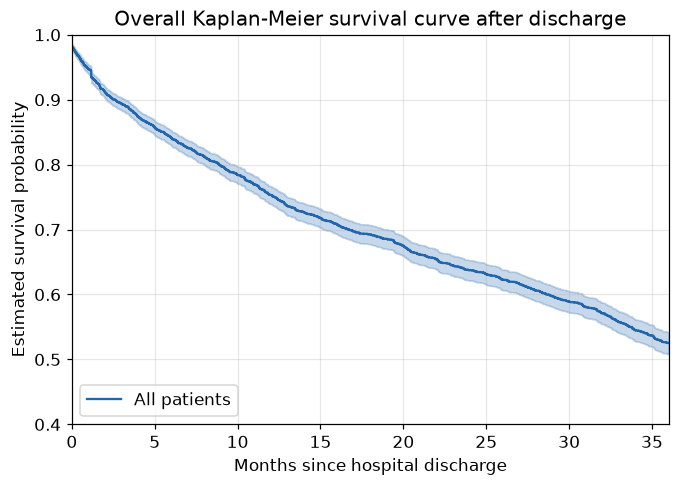

In [6]:
km = KaplanMeierFitter(label="All patients")
km.fit(durations=df[TIME_COL], event_observed=df[EVENT_COL])

fig, ax = plt.subplots(figsize=(7.0, 4.6))
km.plot_survival_function(ax=ax, ci_show=True, color="#2166ac")
ax.set_xlabel("Months since hospital discharge")
ax.set_ylabel("Estimated survival probability")
ax.set_title("Overall Kaplan-Meier survival curve after discharge")
ax.set_xlim(0, MAX_FOLLOWUP)
ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower left")
fig.savefig(os.path.join(FIG_DIR, "fig1_km_overall.png"))
plt.show()

**Figure 1**. Survival falls from 1 at discharge to about 0.53 at 36 months, fastest in the first few months and close to linear thereafter. Around three quarters of the cohort are alive at one year.


## 1.5 Stratified Kaplan-Meier curves

PA1 stratified by sex and by diabetes. Both are reproduced below, each with a log-rank test for equality of the two curves.


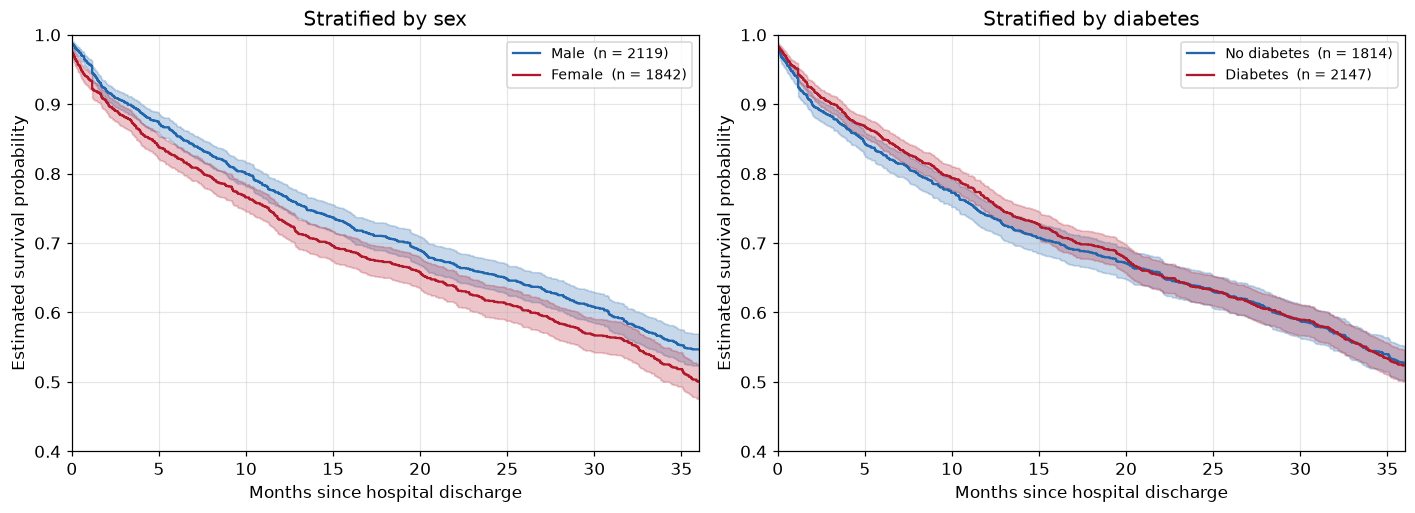

Sex        S(12)|Male = 0.770  S(12)|Female = 0.733
Diabetes   S(12)|No diabetes = 0.740  S(12)|Diabetes = 0.764


In [7]:
PALETTE = ["#2166ac", "#b2182b", "#1b7837"]


def plot_km_strata(ax, data, groups, title, ylim=(0.4, 1.0)):
    # groups: list of (label, boolean mask)
    surv_at_horizon = {}
    for (label, mask), color in zip(groups, PALETTE):
        sub = data[mask]
        f = KaplanMeierFitter(label=f"{label}  (n = {int(mask.sum())})")
        f.fit(durations=sub[TIME_COL], event_observed=sub[EVENT_COL])
        f.plot_survival_function(ax=ax, ci_show=True, color=color)
        surv_at_horizon[label] = float(f.survival_function_at_times([HORIZON]).iloc[0])

    ax.set_xlabel("Months since hospital discharge")
    ax.set_ylabel("Estimated survival probability")
    ax.set_title(title)
    ax.set_xlim(0, MAX_FOLLOWUP)
    ax.set_ylim(*ylim)
    ax.legend(loc="upper right", fontsize=9)
    return surv_at_horizon


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_sex = plot_km_strata(
    axes[0], df,
    [("Male", df["gender_0male_1female"] == 0),
     ("Female", df["gender_0male_1female"] == 1)],
    "Stratified by sex",
)

s_dm = plot_km_strata(
    axes[1], df,
    [("No diabetes", df["diabetes"] == 0),
     ("Diabetes", df["diabetes"] == 1)],
    "Stratified by diabetes",
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_km_stratified.png"))
plt.show()

for name, s in [("Sex", s_sex), ("Diabetes", s_dm)]:
    print(f"{name:10s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

**Figure 2**. Neither of PA1's stratifications separates the cohort. The male curve sits slightly above the female one, 0.77 against 0.73 at one year, but the confidence bands overlap for almost all of the follow-up; the two diabetes curves lie on top of each other.


Two splits that do separate the cohort are age and discharge BUN, both taken at their medians.


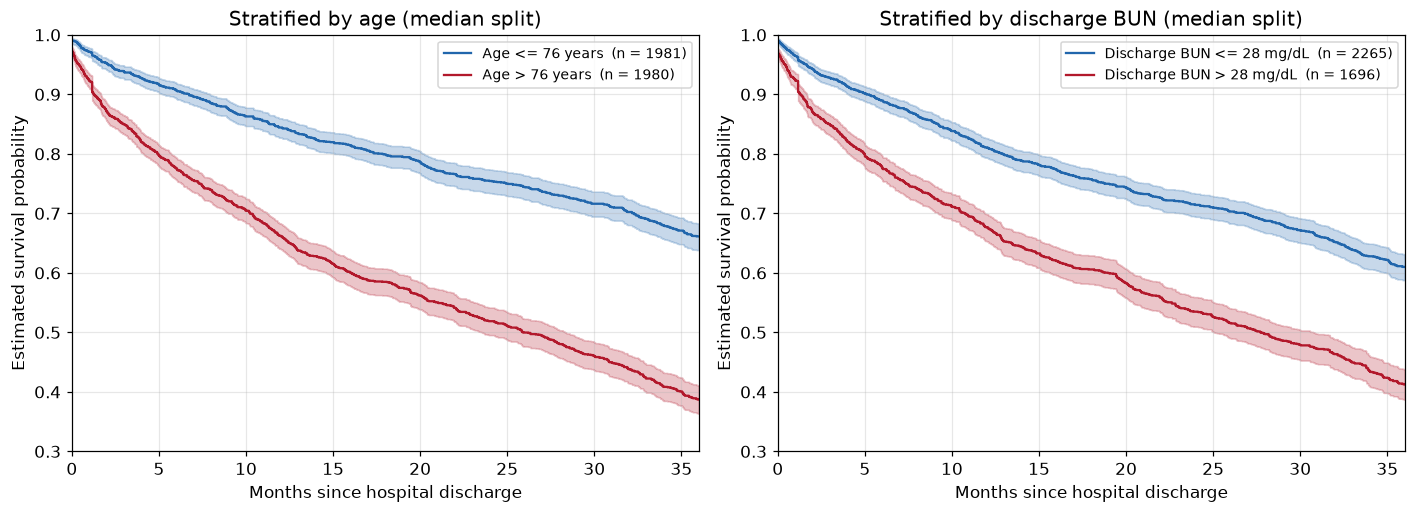

Age            S(12)|Age <= 76 years = 0.844  S(12)|Age > 76 years = 0.661
Discharge BUN  S(12)|Discharge BUN <= 28 mg/dL = 0.810  S(12)|Discharge BUN > 28 mg/dL = 0.676


In [8]:
age_median = df["age_YEARS"].median()
bun_median = df["BUN_discharge"].median()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_age = plot_km_strata(
    axes[0], df,
    [(f"Age <= {age_median:.0f} years", df["age_YEARS"] <= age_median),
     (f"Age > {age_median:.0f} years", df["age_YEARS"] > age_median)],
    "Stratified by age (median split)",
    ylim=(0.3, 1.0),
)

s_bun = plot_km_strata(
    axes[1], df,
    [(f"Discharge BUN <= {bun_median:.0f} mg/dL", df["BUN_discharge"] <= bun_median),
     (f"Discharge BUN > {bun_median:.0f} mg/dL", df["BUN_discharge"] > bun_median)],
    "Stratified by discharge BUN (median split)",
    ylim=(0.3, 1.0),
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_km_age_bun.png"))
plt.show()

for name, s in [("Age", s_age), ("Discharge BUN", s_bun)]:
    print(f"{name:14s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

**Figure 3**. Both splits open a gap early and hold it for the whole three years, with confidence bands that stay clear of each other throughout. Above the median age of 76, one-year survival is 0.66 against 0.84 below it; above a discharge BUN of 28 mg/dL it is 0.68 against 0.81. Sex moved one-year survival by 0.04 and diabetes by nothing at all; these two move it by 0.18 and 0.13.


## 1.6 Research questions motivating the analysis

PA1 closed with a preliminary Cox model on all covariates. Age, RDW, sodium, BUN on admission and discharge, BNP, length of stay, COPD, bilirubin and potassium came out significant; the demographics and most comorbidity indicators did not. Together with the curves above, that gave three questions:

> RQ1. Does the change in BUN during the stay tell us anything about post-discharge survival that the discharge level does not already?
>
> RQ2. Are there interactions between covariates that matter for survival?
>
> RQ3. How well can survival be predicted at the moment of discharge, using only what is known then?


---
# 2. Brief recap of Project Assignment 2

PA2 moved from description to modelling. It replaced the comorbidity flags with the burden variable, fitted a Cox proportional hazards model, tested whether the change in BUN adds anything on top of the discharge level, checked the proportional hazards assumption, and compared the Cox model against a log-normal AFT model for one-year prediction.


## 2.1 The selected model

The model PA2 settled on: sex, age, comorbidity burden (0-1 as the reference level), length of stay, discharge BUN, discharge creatinine, discharge GFR, BNP, white blood cells, sodium, RDW, platelets, bilirubin, potassium and `delta_BUN`.


In [9]:
from lifelines import CoxPHFitter

PA2_FORMULA = ("gender_0male_1female + age_YEARS + C(cat_comorbidities) + "
               "length_of_stay_DAYS + BUN_discharge + creatinine_discharge + GFR_discharge + "
               "BNP + WBC + sodium + RDW + platelets + bilirubin + potassium + delta_BUN")

cox_pa2 = CoxPHFitter().fit(df, duration_col=TIME_COL, event_col=EVENT_COL, formula=PA2_FORMULA)
print(f"Concordance: {cox_pa2.concordance_index_:.4f}")

pa2_hr = (cox_pa2.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
          .round(4).sort_values("p"))
pa2_hr.to_csv(os.path.join(TAB_DIR, "table2_pa2_cox.csv"))
pa2_hr

Concordance: 0.6943


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0438,1.0382,1.0495,0.0000
BUN_discharge,1.0213,1.0176,1.0249,0.0000
sodium,0.9728,0.9627,0.9831,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
delta_BUN,0.9903,0.9867,0.9938,0.0000
RDW,1.1204,1.0903,1.1514,0.0000
length_of_stay_DAYS,1.0094,1.0037,1.0151,0.0011
bilirubin,1.1208,1.0068,1.2477,0.0372
potassium,0.9141,0.8397,0.9951,0.0382


**Table 2**. Significant at the 5% level: age, discharge BUN, sodium, BNP, `delta_BUN`, RDW, length of stay, bilirubin and potassium. Age is 1.044 per year, so a ten-year gap multiplies the hazard by about 1.5; discharge BUN is 1.021 per mg/dL and RDW 1.120 per unit. Sodium and potassium run the other way. BNP is 1.0002 per pg/mL, which is not negligible for a variable running into the thousands.

Neither comorbidity burden level is significant, nor are sex, white blood cells, discharge creatinine, discharge GFR and platelets.


## 2.2 Does the change in BUN add anything?

Yes, which is why `delta_BUN` is in the model above. PA2's likelihood-ratio test against the model without it gave 27.63 on 1 degree of freedom, p = 1.5e-07, so the change over the admission carries information the discharge value alone does not.


## 2.3 Proportional hazards diagnostics

The Cox model assumes each covariate's hazard ratio is constant over follow-up. PA2 checked this with the Schoenfeld residual test on a rank transform of time; the cell below repeats it on the selected model.


In [10]:
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(cox_pa2, df, time_transform="rank")
ph_summary = ph_test.summary[["test_statistic", "p"]].round(4).sort_values("p")
ph_summary.to_csv(os.path.join(TAB_DIR, "table3_ph_test.csv"))

print(f"Covariates with p < 0.05: {int((ph_summary['p'] < 0.05).sum())} of {len(ph_summary)}")
ph_summary

Covariates with p < 0.05: 2 of 16


,test_statistic,p
BUN_discharge,4.3917,0.0361
length_of_stay_DAYS,3.9114,0.0480
creatinine_discharge,2.7398,0.0979
C(cat_comorbidities)[T.4+],2.7004,0.1003
bilirubin,2.4538,0.1172
sodium,1.6433,0.1999
C(cat_comorbidities)[T.2-3],1.3876,0.2388
gender_0male_1female,1.2686,0.2600
age_YEARS,1.0640,0.3023
GFR_discharge,0.8278,0.3629


**Table 3**. Only discharge BUN (0.036) and length of stay (0.048) fall below 0.05, and both only just. Together with PA2's residual plots, the evidence points to mild violations at most.


## 2.4 Cox against the log-normal AFT model

PA2 also fitted a log-normal AFT model on the same covariates. An AFT model acts on survival time rather than on the hazard, so the signs read the other way round. The two models agreed on direction throughout: age, discharge BUN, RDW, bilirubin and length of stay shortened survival, matching hazard ratios above 1, while sodium and `delta_BUN` lengthened it.


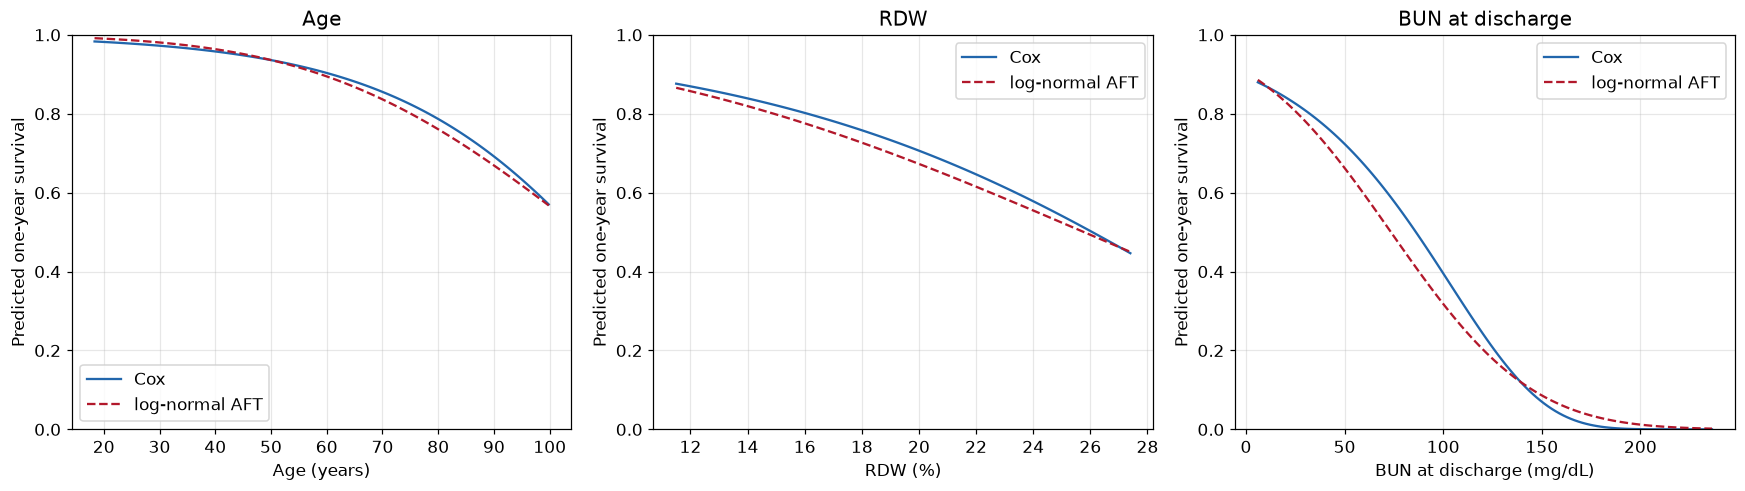

                     representative value
gender_0male_1female                  0.0
age_YEARS                        76.18272
cat_comorbidities                     2-3
length_of_stay_DAYS              5.128474
BUN_discharge                        28.0
creatinine_discharge                 1.23
GFR_discharge                   50.433085
BNP                                 778.1
WBC                                  8.92
sodium                              138.0
RDW                                  15.3
platelets                           225.0
bilirubin                             0.6
potassium                             4.3
delta_BUN                             3.0


In [11]:
from lifelines import LogNormalAFTFitter

# the log-normal AFT model needs strictly positive times
aft_df = df.copy()
aft_df.loc[aft_df[TIME_COL] <= 0, TIME_COL] = 0.01
aft_pa2 = LogNormalAFTFitter().fit(aft_df, duration_col=TIME_COL, event_col=EVENT_COL,
                                   formula=PA2_FORMULA)

MODEL_VARS = ["gender_0male_1female", "age_YEARS", "cat_comorbidities", "length_of_stay_DAYS",
              "BUN_discharge", "creatinine_discharge", "GFR_discharge", "BNP", "WBC", "sodium",
              "RDW", "platelets", "bilirubin", "potassium", "delta_BUN"]


def representative_row(data, columns):
    # median for continuous covariates, most common level for categorical ones
    row = {}
    for col in columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            row[col] = [data[col].median()]
        else:
            row[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(row)


def one_year_curve(model, covariate, grid, base):
    rows = pd.concat([base.assign(**{covariate: v}) for v in grid], ignore_index=True)
    return model.predict_survival_function(rows, times=[HORIZON]).iloc[0].values


base_row = representative_row(df, MODEL_VARS)

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
for ax, cov, label in zip(axes,
                          ["age_YEARS", "RDW", "BUN_discharge"],
                          ["Age (years)", "RDW (%)", "BUN at discharge (mg/dL)"]):
    grid = np.linspace(df[cov].min(), df[cov].max(), 120)
    ax.plot(grid, one_year_curve(cox_pa2, cov, grid, base_row), color="#2166ac", label="Cox")
    ax.plot(grid, one_year_curve(aft_pa2, cov, grid, base_row), color="#b2182b",
            linestyle="--", label="log-normal AFT")
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig4_cox_vs_aft.png"))
plt.show()

print(base_row.T.rename(columns={0: "representative value"}).to_string())

**Figure 4**. Each panel sweeps one covariate across its observed range and holds the rest at the representative values printed below the figure: medians for continuous covariates and the most common comorbidity level.

The two models are almost indistinguishable for age, separate slightly for RDW, and differ most for discharge BUN, where the AFT curve falls faster through the middle of the range and then crosses above the Cox curve in the tail. The BUN axis runs to the observed maximum of 236 mg/dL, but three quarters of patients sit below 39, so nearly all the data lives in the left fifth of that panel.


---
# 3. Research questions

## 3.1 The questions from Project Assignment 1

> RQ1 (PA1). Does the difference between BUN on admission and on discharge have a significant effect on the survival outcome?
>
> RQ2 (PA1). Are there covariate interactions with a significant effect on the survival outcome?
>
> RQ3 (PA1). How accurately can survival be predicted at hospital discharge?

The first has been answered: PA2's likelihood-ratio test on `delta_BUN` was significant, so the change over the admission does carry information beyond the discharge value.

The second was never addressed, since neither assignment fitted an interaction term. As phrased it also does not say which interactions to look for, and testing every pair would produce significant results by chance alone. We keep the question, narrowed to two interactions chosen in advance (Section 3.2).

The third was not addressed either. PA1 and PA2 both fitted models to the full dataset and reported in-sample summaries, so neither produced an honest estimate of how well survival can be predicted.


## 3.2 Final research questions

> **RQ1.** How accurately can one-year survival be predicted from the information available at discharge, and do the more flexible models predict better than the Cox model?

PA1's third question made specific. Section 4 splits the data, Sections 5 and 7 fit the four models on the training set, and Section 9 compares them on the test set.

> **RQ2.** Where the more flexible models differ from the Cox model, which of the Cox model's assumptions is responsible?

The Cox model assumes three separate things: that each covariate acts linearly on the log hazard, that covariate effects add together without interacting, and that hazard ratios stay constant over follow-up. The added models give up different combinations. DeepSurv replaces the linear predictor with a neural network, so it allows non-linear effects and interactions but keeps hazards proportional. Cox-Time also lets the risk score depend on time, so hazard ratios need not be constant. The random survival forest assumes none of the three, since it splits recursively and estimates a separate cumulative hazard in each terminal node.

Section 2.3 gives a concrete reason to ask, as proportional hazards came out borderline for discharge BUN and length of stay. Section 8 shows whether the flexible models see age, RDW and discharge BUN the way the Cox model does, and Section 9 whether any of the differences improves prediction.

> **RQ3.** Do the two interactions specified below improve on the additive Cox model?

PA1's second question, narrowed to two terms fixed in advance rather than a search over all 105 pairs. The first is `delta_BUN` with `BUN_discharge`: the change and the level are tied by construction, and the same change plausibly means different things depending on the level the patient reached, which the additive model cannot express. The second is age with `BUN_discharge`, the two strongest predictors in Table 2, since whether reduced kidney clearance carries the same risk at 60 as at 85 has a clear reading either way. Each is a single term added to the Section 5 model and tested by a likelihood-ratio test on the training data in Section 10.


---
# 4. Train-test split

An 80/20 split into a training and a test set, with the random seed fixed at 42 — set in Section 0 and used for every random step in the project. The split is stratified by the event indicator, so both sets carry close to the same proportion of deaths.


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df[EVENT_COL]
)

split_summary = pd.DataFrame(
    {
        "n": [len(train_df), len(test_df)],
        "events": [int(train_df[EVENT_COL].sum()), int(test_df[EVENT_COL].sum())],
        "event rate": [train_df[EVENT_COL].mean(), test_df[EVENT_COL].mean()],
        "deaths by 12 months": [
            int(((train_df[EVENT_COL] == 1) & (train_df[TIME_COL] <= HORIZON)).sum()),
            int(((test_df[EVENT_COL] == 1) & (test_df[TIME_COL] <= HORIZON)).sum()),
        ],
    },
    index=["Training", "Test"],
).round(4)

print(f"Random seed: {SEED}")
split_summary

Random seed: 42


,n,events,event rate,deaths by 12 months
Training,3168,1343,0.4239,748
Test,793,336,0.4237,199


**Table 4**. 3,168 patients for training and 793 for testing, with an event rate of 42.4% in both.


---
# 5. Refitting the selected Cox model

## 5.1 Estimates on the training data

PA2's model, refitted on the training patients only, with the full-data estimates of Section 2 alongside.


In [13]:
import joblib

MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [14]:
# check if model exists
if os.path.exists(os.path.join(MODEL_DIR, "cox_train.joblib")):
    cox_train = joblib.load(os.path.join(MODEL_DIR, "cox_train.joblib"))
else:
    cox_train = CoxPHFitter().fit(train_df, duration_col=TIME_COL, event_col=EVENT_COL,
                                  formula=PA2_FORMULA)
    joblib.dump(cox_train, os.path.join(MODEL_DIR, "cox_train.joblib"))

train_vs_full = pd.DataFrame({
    "HR (train)": cox_train.hazard_ratios_,
    "lower 95%": cox_train.summary["exp(coef) lower 95%"],
    "upper 95%": cox_train.summary["exp(coef) upper 95%"],
    "p (train)": cox_train.summary["p"],
    "HR (full)": cox_pa2.hazard_ratios_,
    "p (full)": cox_pa2.summary["p"],
})
train_vs_full["HR change %"] = 100 * (train_vs_full["HR (train)"] / train_vs_full["HR (full)"] - 1)
train_vs_full = train_vs_full.sort_values("p (full)").round(4)
train_vs_full.to_csv(os.path.join(TAB_DIR, "table5_cox_train_vs_full.csv"))

inside = ((train_vs_full["HR (full)"] >= train_vs_full["lower 95%"]) &
          (train_vs_full["HR (full)"] <= train_vs_full["upper 95%"])).all()
print(f"Training set: {len(train_df)} patients, {int(train_df[EVENT_COL].sum())} events")
print(f"Concordance: {cox_train.concordance_index_:.4f} on training, "
      f"{cox_pa2.concordance_index_:.4f} for the full-data fit")
print(f"Largest change in any hazard ratio: {train_vs_full['HR change %'].abs().max():.1f}%")
print(f"Every full-data hazard ratio inside the training 95% CI: {inside}")
train_vs_full

Training set: 3168 patients, 1343 events
Concordance: 0.6995 on training, 0.6943 for the full-data fit
Largest change in any hazard ratio: 2.2%
Every full-data hazard ratio inside the training 95% CI: True


,HR (train),lower 95%,upper 95%,p (train),HR (full),p (full),HR change %
covariate,,,,,,,
age_YEARS,1.0447,1.0384,1.0511,0.0000,1.0438,0.0000,0.0847
BUN_discharge,1.0238,1.0197,1.0279,0.0000,1.0213,0.0000,0.2476
RDW,1.1295,1.0963,1.1638,0.0000,1.1204,0.0000,0.8157
delta_BUN,0.9900,0.9861,0.9940,0.0000,0.9903,0.0000,-0.0225
BNP,1.0002,1.0001,1.0002,0.0000,1.0002,0.0000,0.0001
sodium,0.9726,0.9611,0.9843,0.0000,0.9728,0.0000,-0.0236
length_of_stay_DAYS,1.0083,1.0020,1.0146,0.0100,1.0094,0.0011,-0.1081
bilirubin,1.0988,0.9738,1.2400,0.1263,1.1208,0.0372,-1.9582
potassium,0.9196,0.8376,1.0096,0.0784,0.9141,0.0382,0.5936


**Table 5**. The estimates are stable. No hazard ratio moves by more than 2.2%, every full-data estimate falls inside the corresponding training confidence interval, and concordance is 0.699 on training against 0.694 for the full-data fit.

Bilirubin (p from 0.037 to 0.126) and potassium (0.038 to 0.078) lose significance, but neither effect actually changed: 1.121 to 1.099 and 0.914 to 0.920. What changed is the width of the intervals once a fifth of the data was set aside, and both were marginal to begin with. Age, discharge BUN, sodium, BNP, `delta_BUN`, RDW and length of stay all remain significant with essentially unchanged hazard ratios, so the conclusions do not change meaningfully.

`delta_BUN` needs one clarification, since a hazard ratio below 1 reads as if a rise in BUN during the stay were protective. Because `delta_BUN` is discharge minus admission and the discharge level is also in the model, its coefficient is exactly minus the effect of the admission level at a fixed discharge level: 0.990 per mg/dL of rise says the same thing as 1.010 per mg/dL of admission BUN. The model therefore says that of two patients leaving with the same BUN, the one who started higher does worse — the expected direction, and the reading used again in Section 10.3.


## 5.2 Proportional hazards on the training data

The same Schoenfeld residual test as in Section 2.3, now on the refitted model, with the full-data p-values alongside.


In [15]:
ph_train = proportional_hazard_test(cox_train, train_df, time_transform="rank").summary
ph_full = proportional_hazard_test(cox_pa2, df, time_transform="rank").summary

ph_compare = pd.DataFrame({
    "statistic (train)": ph_train["test_statistic"],
    "p (train)": ph_train["p"],
    "statistic (full)": ph_full["test_statistic"],
    "p (full)": ph_full["p"],
}).sort_values("p (train)").round(4)
ph_compare.to_csv(os.path.join(TAB_DIR, "table6_ph_train_vs_full.csv"))

flagged_train = list(ph_compare.index[ph_compare["p (train)"] < 0.05])
flagged_full = list(ph_compare.index[ph_compare["p (full)"] < 0.05])
print(f"Flagged on training data ({len(flagged_train)} of {len(ph_compare)}): {flagged_train}")
print(f"Flagged on full data     ({len(flagged_full)} of {len(ph_compare)}): {flagged_full}")
print(f"Flagged in both: {sorted(set(flagged_train) & set(flagged_full)) or 'none'}")
ph_compare

Flagged on training data (3 of 16): ['C(cat_comorbidities)[T.4+]', 'C(cat_comorbidities)[T.2-3]', 'bilirubin']
Flagged on full data     (2 of 16): ['BUN_discharge', 'length_of_stay_DAYS']
Flagged in both: none


,statistic (train),p (train),statistic (full),p (full)
C(cat_comorbidities)[T.4+],5.3661,0.0205,2.7004,0.1003
C(cat_comorbidities)[T.2-3],5.0600,0.0245,1.3876,0.2388
bilirubin,4.4517,0.0349,2.4538,0.1172
creatinine_discharge,3.1585,0.0755,2.7398,0.0979
BUN_discharge,2.4654,0.1164,4.3917,0.0361
length_of_stay_DAYS,2.2173,0.1365,3.9114,0.0480
delta_BUN,2.1407,0.1434,0.6245,0.4294
gender_0male_1female,1.7093,0.1911,1.2686,0.2600
GFR_discharge,1.0308,0.3100,0.8278,0.3629
potassium,0.9632,0.3264,0.6007,0.4383


**Table 6**. The formal test gives a different answer on the training data. Discharge BUN and length of stay, the two flagged on the full data, rise to 0.116 and 0.137, while both comorbidity burden levels and bilirubin fall below 0.05 instead. No covariate is flagged in both fits.

The training set is not independent data — those patients are most of the full cohort — so a hazard ratio that genuinely varied over follow-up would still vary in the subset. Flags that swap like this are noise, and the smallest p-value anywhere in either fit is 0.021. As in Section 2.3, proportional hazards is an adequate approximation, and the hazard ratios in Table 5 describe an average effect over follow-up.


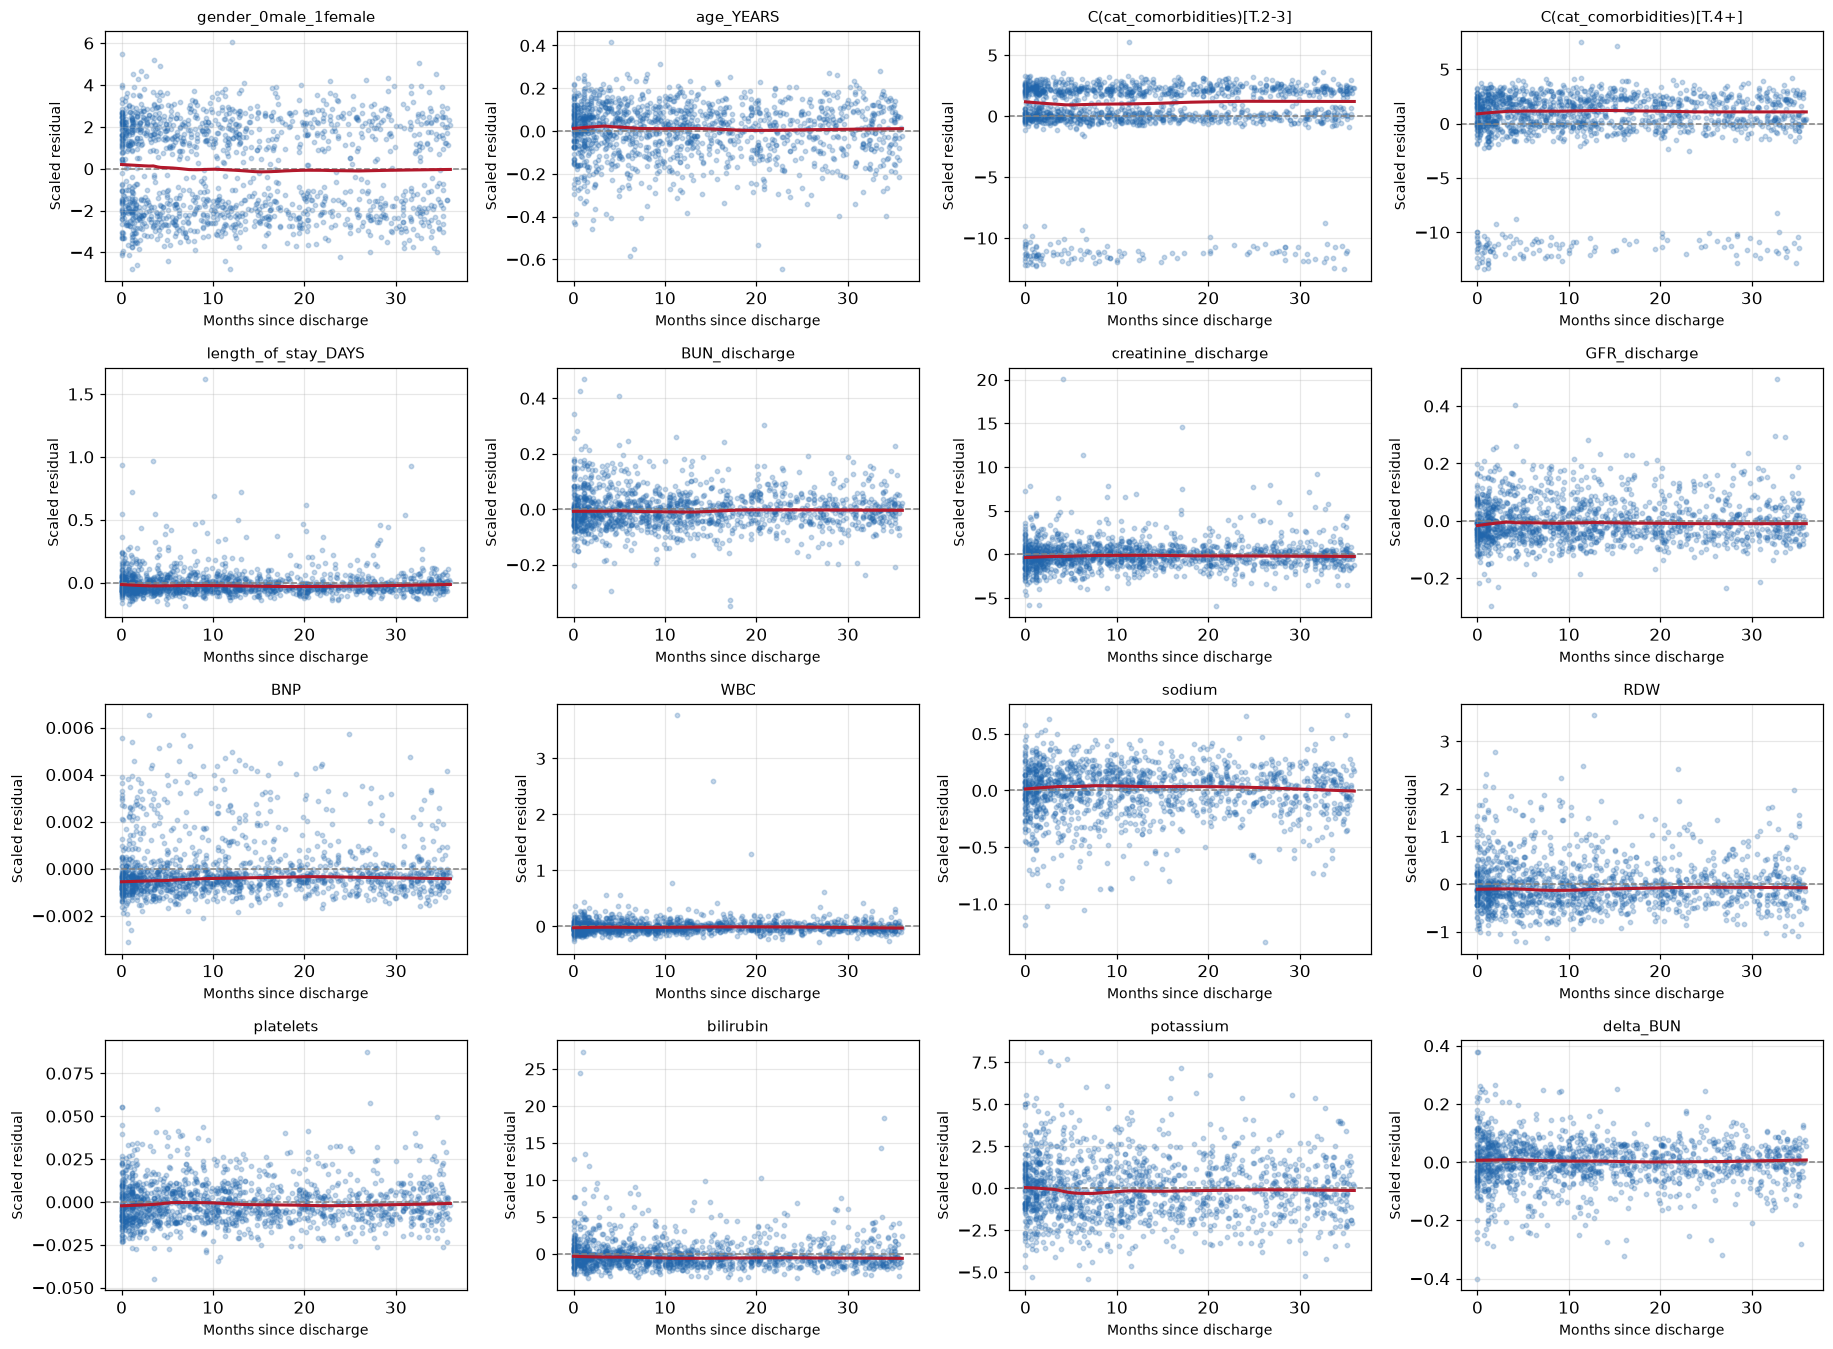

In [16]:
from statsmodels.nonparametric.smoothers_lowess import lowess

schoenfeld = cox_train.compute_residuals(train_df, kind="scaled_schoenfeld")
event_times = train_df.loc[schoenfeld.index, TIME_COL]

n_cols = 4
n_rows = int(np.ceil(len(schoenfeld.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.1 * n_rows))
axes = axes.flatten()

for ax, covariate in zip(axes, schoenfeld.columns):
    x = event_times.values
    y = schoenfeld[covariate].values
    order = np.argsort(x)
    x, y = x[order], y[order]

    ax.scatter(x, y, alpha=0.25, s=8, color="#2166ac")
    ax.axhline(0, linestyle="--", linewidth=1, color="grey")
    smoothed = lowess(y, x, frac=0.4, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="#b2182b")
    ax.set_title(covariate, fontsize=10)
    ax.set_xlabel("Months since discharge", fontsize=9)
    ax.set_ylabel("Scaled residual", fontsize=9)

for j in range(len(schoenfeld.columns), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig5_schoenfeld_train.png"))
plt.show()

**Figure 5**. Scaled Schoenfeld residuals against time since discharge for every term in the refitted model, each with a lowess smoother.

The smoothers are close to flat almost everywhere, with none of the steady drift a genuinely time-varying hazard ratio would produce, and the terms flagged in Table 6 look no different by eye from the rest. The comorbidity panels fall into bands rather than a cloud because the variable enters as dummy indicators, which is a feature of the coding and not evidence of a violation. Graphical and formal evidence agree that the assumption holds well enough here.


---
# 6. One-year survival prediction using the refitted Cox model

lifelines centres the covariates, so the fitted one-year survival probability is

$\hat S(12 \mid X) = \hat S_0(12)^{\exp((X - \bar X)^T \hat \beta)}$

with $\hat S_0$ the Breslow baseline on the training data and $\bar X$ the training-set covariate means. $\hat S_0(12)$ is therefore the prediction for a patient at those means, not for one with every covariate at zero.

Each plot varies one covariate and holds the others at representative values from the training set: the median for continuous covariates and the most common level for comorbidity burden. Sex is the only binary covariate, and its median coincides with its most common category, so taking medians throughout gives the required representative patient.

The grids run from the 1st to the 99th percentile of each covariate rather than from the minimum to the maximum. Discharge BUN reaches 199.7 mg/dL in the training set but its upper quartile is 38, so the full range would spend most of the axis where almost no patients are. Section 8 reuses these grids and this representative patient.


Baseline S0(12 months)              = 0.7896
Representative patient S(12 months) = 0.8207


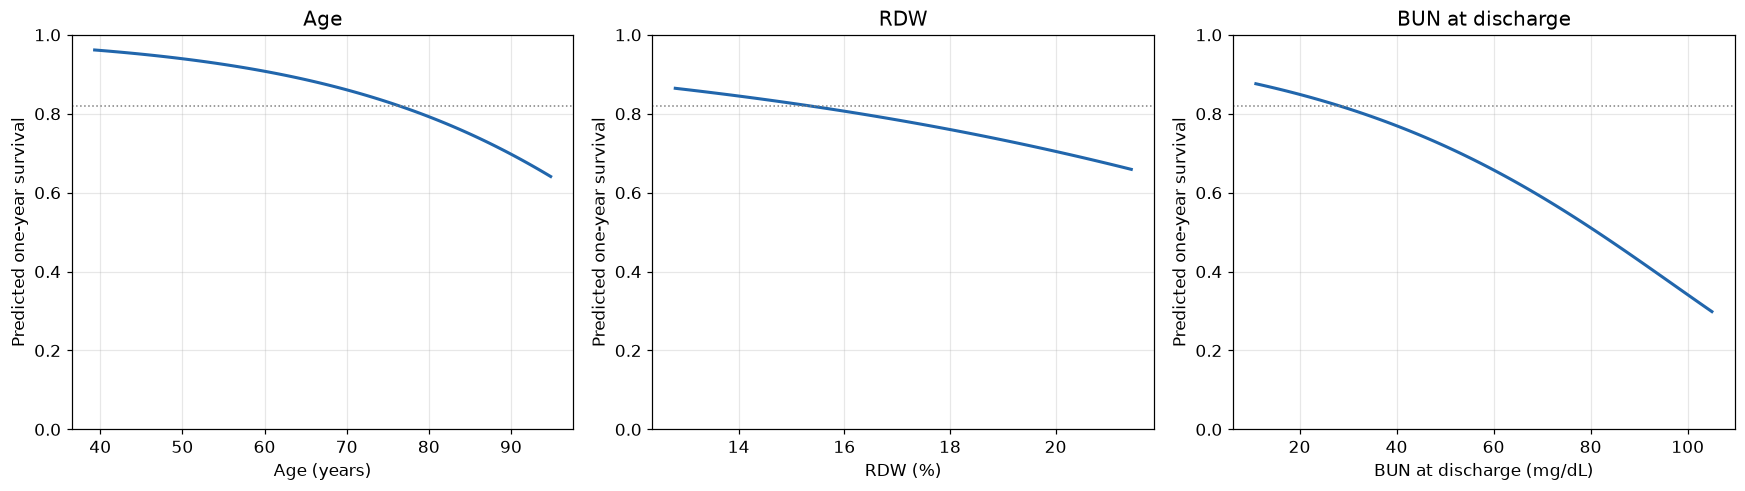


                     representative value
gender_0male_1female                  0.0
age_YEARS                        76.27293
cat_comorbidities                     2-3
length_of_stay_DAYS              5.106984
BUN_discharge                        28.0
creatinine_discharge                 1.23
GFR_discharge                   50.433085
BNP                                 778.1
WBC                                  8.92
sodium                              138.0
RDW                                  15.3
platelets                           225.0
bilirubin                             0.6
potassium                             4.3
delta_BUN                            2.59



,grid low,grid high,S at grid low,S at grid high,drop over grid,Q1,Q3,S at Q1,S at Q3,drop over IQR
covariate,,,,,,,,,,
Age (years),39.323,94.831,0.962,0.641,0.321,67.094,83.143,0.876,0.766,0.110
RDW (%),12.800,21.433,0.864,0.659,0.205,14.500,16.200,0.836,0.802,0.034
BUN at discharge (mg/dL),11.000,105.000,0.876,0.298,0.577,22.000,38.000,0.842,0.779,0.064


In [17]:
PLOT_COVARIATES = {
    "age_YEARS": "Age (years)",
    "RDW": "RDW (%)",
    "BUN_discharge": "BUN at discharge (mg/dL)",
}

base_train = representative_row(train_df, MODEL_VARS)
plot_grids = {}
for covariate in PLOT_COVARIATES:
    low, high = train_df[covariate].quantile([0.01, 0.99])
    plot_grids[covariate] = np.linspace(low, high, 120)

baseline = cox_train.baseline_survival_
s0_year = baseline[baseline.index <= HORIZON].iloc[-1, 0]
s_rep = float(cox_train.predict_survival_function(base_train, times=[HORIZON]).iloc[0, 0])
print(f"Baseline S0(12 months)              = {s0_year:.4f}")
print(f"Representative patient S(12 months) = {s_rep:.4f}")

summary_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
for ax, (covariate, label) in zip(axes, PLOT_COVARIATES.items()):
    grid = plot_grids[covariate]
    curve = one_year_curve(cox_train, covariate, grid, base_train)
    ax.plot(grid, curve, color="#2166ac", linewidth=2)
    ax.axhline(s_rep, color="grey", linestyle=":", linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)

    q1, q3 = train_df[covariate].quantile([0.25, 0.75])
    s_q1, s_q3 = one_year_curve(cox_train, covariate, np.array([q1, q3]), base_train)
    summary_rows.append([label, grid[0], grid[-1], curve[0], curve[-1], curve[0] - curve[-1],
                         q1, q3, s_q1, s_q3, s_q1 - s_q3])

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig6_cox_one_year.png"))
plt.show()

prediction_ranges = pd.DataFrame(summary_rows, columns=[
    "covariate", "grid low", "grid high", "S at grid low", "S at grid high", "drop over grid",
    "Q1", "Q3", "S at Q1", "S at Q3", "drop over IQR"]).set_index("covariate").round(3)
prediction_ranges.to_csv(os.path.join(TAB_DIR, "table7_cox_prediction_ranges.csv"))

print()
print(base_train.T.rename(columns={0: "representative value"}).to_string())
print()
prediction_ranges

**Figure 6**. The representative patient — a man of 76 with two or three comorbidities, discharge BUN of 28 mg/dL and RDW of 15.3 — has a predicted one-year survival of 0.821. That is the dotted line in each panel, which each curve crosses at the covariate's median. The baseline $\hat S_0(12) = 0.790$ is the prediction at the training covariate means, a little below the median patient.

Across the plotted range discharge BUN moves the prediction furthest, from 0.876 at 11 mg/dL down to 0.298 at 105, then age (0.962 to 0.641) and RDW (0.864 to 0.659). Over the interquartile range the order reverses: age drops predicted survival by 0.11, discharge BUN by 0.06 and RDW by 0.03. Age therefore separates predictions most for a patient in the middle of the distribution, while discharge BUN dominates the plotted range because of its long right tail and matters most for the minority discharged with high values.

All three curves decline monotonically and flatten as survival falls, which is a property of the model rather than a finding: with a linear predictor, a number below one raised to a growing power can only behave this way.


---
# 7. Fitting additional survival prediction models

A random survival forest, DeepSurv and Cox-Time, all on the same covariates as the refitted Cox model, so that anything separating them comes from the model and not from the information it was given. Each gives up a different part of the Cox model, which is what RQ2 asks about: DeepSurv drops linearity and additivity, Cox-Time drops proportional hazards as well, and the forest assumes none of the three.

Every model is tuned on the training data and refit on all training patients. The test set is not touched until Section 9.


## 7.1 Validation procedure

The Cox model was fitted from a formula, so lifelines built its own design matrix; the other three need it explicitly, as the continuous covariates plus the two comorbidity dummies of Table 5. `cat_comorbidities` is a categorical variable, so `get_dummies` returns the same columns for any subset of the data, including the test set.

Hyperparameters are chosen by 5-fold cross-validation inside the training set, with the folds drawn once and reused for all three models. Each configuration is scored by the integrated Brier score over the first year, the measure Section 9.3 defines and reports. Cross-validation is used rather than a single held-out block because only about a fifth of the cohort dies within the first year, so one split would mostly rank noise.

Mean IBS alone is not enough to choose: nearby configurations are close enough that the outright minimum is often noise. We use a one-standard-error rule instead — among the configurations within one SE of the best, keep the simplest — and refit that configuration on the whole training set. The Cox model is scored on the same folds as a reference row.

The number of epochs is not part of any grid. Inside each fold a further 20% of the fitting data is held out for early stopping, which restores the weights of the best epoch, so what is recorded is that epoch rather than the number of epochs run. The final networks train on all training patients for the average of those counts; a fold fits on fewer patients, so the transferred count is an approximation.

Each fitted model is saved to `trained_models/` as it is produced, so Sections 8 to 10 load them instead of repeating the search.


In [18]:
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.metrics import brier_score

CAT_COL = "cat_comorbidities"
NUMERIC_VARS = [c for c in MODEL_VARS if c != CAT_COL]
EVAL_TIMES = np.arange(1.0, HORIZON + 1.0)      # months 1 to 12
FOLDS = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(train_df))


def design_matrix(data):
    # the sixteen terms of Table 5: fourteen continuous covariates and two comorbidity dummies
    dummies = pd.get_dummies(data[CAT_COL], prefix="comorb", drop_first=True)
    return pd.concat([data[NUMERIC_VARS], dummies], axis=1).astype("float32")


def surv_target(data):
    return Surv.from_arrays(event=data[EVENT_COL].astype(bool), time=data[TIME_COL])


def target_tuple(data):
    return (data[TIME_COL].values.astype("float32"), data[EVENT_COL].values.astype("float32"))


def surv_at_times(curves, times):
    """Step-function lookup on curves whose index is time: one row per patient, one column per time."""
    return curves.reindex(curves.index.union(times)).ffill().fillna(1.0).loc[times].T.to_numpy()


def integrated_bs(bs):
    """(1/12) times the trapezoidal integral of the IPCW Brier score over months 0 to 12.

    BS(0) = 0 exactly -- every patient is alive at discharge and every model predicts S(0) = 1 --
    so that point is prepended to the monthly scores and the integral starts at zero.
    """
    return np.trapezoid(np.r_[0.0, bs], np.r_[0.0, EVAL_TIMES]) / HORIZON


def one_year_ibs(curves, d_fit, d_val):
    # IPCW weights come from the fitting folds, the predictions from the held-out fold
    _, bs = brier_score(surv_target(d_fit), surv_target(d_val),
                        surv_at_times(curves, EVAL_TIMES), EVAL_TIMES)
    return integrated_bs(bs)


def cv_search(fit_fold, grid):
    """Mean and SE of the cross-validated IBS for every configuration in `grid`, best first."""
    rows = []
    for params in grid:
        scores, epochs = [], []
        for fit_idx, val_idx in FOLDS:
            d_fit, d_val = train_df.iloc[fit_idx], train_df.iloc[val_idx]
            curves, n_epochs = fit_fold(params, d_fit, d_val)
            scores.append(one_year_ibs(curves, d_fit, d_val))
            epochs.append(n_epochs)
        rows.append({**params, "IBS": np.mean(scores),
                     "IBS_SE": np.std(scores, ddof=1) / np.sqrt(len(scores)),
                     "epochs": np.mean(epochs)})
    return pd.DataFrame(rows).sort_values("IBS").reset_index(drop=True)


def best_of(results, complexity=None):
    """The winning configuration and its row.

    With no `complexity`, the outright best (lowest mean IBS). With `complexity` (a function
    mapping a results row to a sortable "simplicity" key, smallest = simplest), the simplest
    configuration among those within one SE of the best -- a one-standard-error rule.
    """
    candidates = results
    if complexity is not None:
        threshold = results["IBS"].iloc[0] + results["IBS_SE"].iloc[0]
        candidates = results[results["IBS"] <= threshold].copy()
        candidates["_complexity"] = candidates.apply(complexity, axis=1)
        candidates = candidates.sort_values("_complexity")
    row = candidates.iloc[0]
    drop_cols = [c for c in ["IBS", "IBS_SE", "epochs", "_complexity"] if c in row.index]
    params = row.drop(drop_cols)
    # pandas widens a row to float; put the integer-valued settings back
    params = {k: int(v) if isinstance(v, float) and v.is_integer() else v for k, v in params.items()}
    return params, row


def fit_cox_fold(params, d_fit, d_val):
    # a reference row: the refitted Cox model of Section 5, scored on the same five folds
    model = CoxPHFitter().fit(d_fit, duration_col=TIME_COL, event_col=EVENT_COL, formula=PA2_FORMULA)
    return model.predict_survival_function(d_val), np.nan


X_train = design_matrix(train_df)
y_train = surv_target(train_df)
print(f"Design columns ({X_train.shape[1]}): {', '.join(X_train.columns)}")
print(f"{len(FOLDS)}-fold cross-validation on {len(train_df)} training patients, "
      f"scored by IBS over months {EVAL_TIMES[0]:.0f} to {EVAL_TIMES[-1]:.0f}")

cox_results = cv_search(fit_cox_fold, [{}])
print(f"Cox (reference row, same folds): CV IBS = {cox_results.iloc[0]['IBS']:.4f} "
      f"+/- {cox_results.iloc[0]['IBS_SE']:.4f}")

Design columns (16): gender_0male_1female, age_YEARS, length_of_stay_DAYS, BUN_discharge, creatinine_discharge, GFR_discharge, BNP, WBC, sodium, RDW, platelets, bilirubin, potassium, delta_BUN, comorb_2-3, comorb_4+
5-fold cross-validation on 3168 training patients, scored by IBS over months 1 to 12
Cox (reference row, same folds): CV IBS = 0.1097 +/- 0.0030


## 7.2 Random survival forest

The forest grows 500 trees on bootstrap samples of the training data. Each node splits on the covariate and cut point maximising the log-rank statistic between the two children, each terminal node carries the Nelson-Aalen cumulative hazard of the training patients that fall into it, and a patient's survival curve is the average over trees of the curve in the node they reach.

Two hyperparameters are tuned:

* `min_samples_leaf` over 5, 15, 30, 50 — how many patients stand behind each terminal estimate, and the main bias-variance knob. At a 42% event rate a leaf of 5 holds about two deaths and gives a very noisy curve, a leaf of 50 a smooth but coarse one.
* `max_features` over 4, 8, 16, from the usual square root of the number of columns up to all of them. Restricting features decorrelates the trees, but with so few columns and most of the signal in age, discharge BUN and RDW, sampling four per split often leaves the strong covariates unavailable, so the choice is settled empirically.

The rest is fixed: 500 trees, since more trees only reduce the variance of the average and cannot overfit, and `min_samples_split` at twice the leaf size with unbounded depth, both redundant once the leaf size is tuned. Averaging trees removes most of a single leaf's noise, so a small leaf can still score well in cross-validation; the one-standard-error rule pulls the choice back toward larger leaves whenever a simpler configuration scores within noise of the best.


In [19]:
from sksurv.ensemble import RandomSurvivalForest

RSF_TREES = 500
RSF_GRID = list(ParameterGrid({"min_samples_leaf": [5, 15, 30, 50], "max_features": [4, 8, 16]}))


def rsf_complexity(row):
    # simpler = larger leaves first, fewer features per split as a tie-break
    return (-row["min_samples_leaf"], row["max_features"])


def make_rsf(params):
    leaf = int(params["min_samples_leaf"])
    return RandomSurvivalForest(n_estimators=RSF_TREES, random_state=SEED, n_jobs=-1,
                                min_samples_leaf=leaf, min_samples_split=2 * leaf,
                                max_features=int(params["max_features"]))


def rsf_surv(model, data):
    curves = model.predict_survival_function(design_matrix(data), return_array=True)
    return pd.DataFrame(curves.T, index=model.unique_times_)


def fit_rsf_fold(params, d_fit, d_val):
    model = make_rsf(params).fit(design_matrix(d_fit), surv_target(d_fit))
    return rsf_surv(model, d_val), np.nan


# check if RSF model exists
if os.path.exists(os.path.join(MODEL_DIR, "rsf.joblib")):
    rsf, rsf_params, rsf_row = joblib.load(os.path.join(MODEL_DIR, "rsf.joblib"))
else:
    rsf_results = cv_search(fit_rsf_fold, RSF_GRID)
    rsf_params, rsf_row = best_of(rsf_results, complexity=rsf_complexity)   
    rsf = make_rsf(rsf_params).fit(X_train, y_train)
    joblib.dump((rsf, rsf_params, rsf_row), os.path.join(MODEL_DIR, "rsf.joblib"))

print("Selected:", ", ".join(f"{k} = {v}" for k, v in rsf_params.items()),
      f"   CV IBS: {rsf_row['IBS']:.4f} +/- {rsf_row['IBS_SE']:.4f}")

Selected: max_features = 4, min_samples_leaf = 50    CV IBS: 0.1116 +/- 0.0033


## 7.3 DeepSurv

DeepSurv keeps the Cox partial likelihood and replaces the linear predictor with a neural network, so a patient's log relative risk is $g(X)$ rather than $X^T \beta$ and survival is read as in Section 6,

$\hat S(t \mid X) = \hat S_0(t)^{\exp(g(X))}$,

with $\hat S_0$ the Breslow estimator on the training data. Hazards stay proportional, since $e^{g(x_1) - g(x_2)}$ does not involve $t$; what the network adds is a risk score free to bend with each covariate and to let covariates modify one another.

Three hyperparameters are tuned:

* hidden layers over [16], [32, 32] and [64, 64]. This decides how much non-linearity the model can express and is the main overfitting risk at this sample size. A single layer of 16 is close to the Cox model and serves as a floor: if it wins, the flexibility is not being used.
* dropout over 0.1 and 0.4, the main regulariser, so that the larger networks are not judged on overfitting alone.
* learning rate over 0.01 and 0.001. At batch size 256 an epoch is about ten updates, so Adam at 0.01 takes few large steps, which together with batch normalisation can be unstable.

Fixed: Adam, batch size 256, at most 512 epochs, early stopping after 10 epochs without improvement with the best weights restored, and no output bias, since a constant in $g$ would be absorbed into the baseline hazard. The covariates are standardised because gradient descent needs them on a common scale, with the scaler fitted on the data the network trains on.


In [20]:
import warnings
import torch
import torchtuples as tt
from pycox.models import CoxPH, CoxTime
from pycox.models.cox_time import MLPVanillaCoxTime

# torchtuples indexes with a list rather than a tuple in a few internal spots; harmless with the
# pinned torch version here but noisy across ~120 fold fits, so it is silenced rather than printed
warnings.filterwarnings("ignore", category=UserWarning, module="torchtuples")

BATCH_SIZE = 256
MAX_EPOCHS = 512
PATIENCE = 10
NET_GRID = list(ParameterGrid({"hidden": [[16], [32, 32], [64, 64]],
                               "dropout": [0.1, 0.4], "lr": [0.01, 0.001]}))


def net_complexity(row):
    # simpler = fewer/smaller hidden units first, higher dropout as a tie-break
    return (sum(row["hidden"]), -row["dropout"])


def train_net(params, data, cox_time, epochs=None, stop_data=None):
    """Fit one network on `data`, stopping on `stop_data` if given, else running `epochs` epochs.

    Returns the epoch of the best validation loss when early stopping is used -- `EarlyStopping`
    keeps training for `PATIENCE` epochs past that point and restores the best weights, so the
    number of epochs run is not the number that should be transferred to the final fit.
    """
    scaler = StandardScaler().fit(design_matrix(data))
    x, y = scaler.transform(design_matrix(data)).astype("float32"), target_tuple(data)
    labtrans = CoxTime.label_transform() if cox_time else None
    if cox_time:
        y = labtrans.fit_transform(*y)

    torch.manual_seed(SEED)
    if cox_time:
        net = MLPVanillaCoxTime(x.shape[1], params["hidden"], batch_norm=True, dropout=params["dropout"])
        model = CoxTime(net, tt.optim.Adam(params["lr"]), labtrans=labtrans)
    else:
        net = tt.practical.MLPVanilla(x.shape[1], params["hidden"], out_features=1, batch_norm=True,
                                      dropout=params["dropout"], output_bias=False)
        model = CoxPH(net, tt.optim.Adam(params["lr"]))

    callbacks, val_data = [], None
    if stop_data is not None:
        y_stop = target_tuple(stop_data)
        val_data = tt.tuplefy(scaler.transform(design_matrix(stop_data)).astype("float32"),
                              labtrans.transform(*y_stop) if cox_time else y_stop)
        if cox_time:
            val_data = val_data.repeat(10).cat()   # the case-control loss is sampled
        callbacks, epochs = [tt.callbacks.EarlyStopping(patience=PATIENCE)], MAX_EPOCHS

    log = model.fit(x, y, batch_size=BATCH_SIZE, epochs=epochs, callbacks=callbacks,
                    val_data=val_data, verbose=False)
    model.compute_baseline_hazards()

    log_df = log.to_pandas()
    n_epochs = len(log_df)
    if stop_data is not None:
        val_col = "val_loss" if "val_loss" in log_df.columns else log_df.columns[-1]
        n_epochs = int(log_df[val_col].idxmin()) + 1   # epoch of the best (restored) weights
    return model, scaler, n_epochs


def net_surv(model, scaler, data):
    return model.predict_surv_df(scaler.transform(design_matrix(data)).astype("float32"))


def fit_net_fold(params, d_fit, d_val, cox_time):
    d_fit, d_stop = train_test_split(d_fit, test_size=0.2, random_state=SEED,
                                     stratify=d_fit[EVENT_COL])
    model, scaler, epochs = train_net(params, d_fit, cox_time, stop_data=d_stop)
    return net_surv(model, scaler, d_val), epochs

if os.path.exists(os.path.join(MODEL_DIR, "deepsurv.joblib")):
    deepsurv, deepsurv_scaler, ds_params, ds_row = joblib.load(os.path.join(MODEL_DIR, "deepsurv.joblib"))
else:
    ds_results = cv_search(lambda p, a, b: fit_net_fold(p, a, b, cox_time=False), NET_GRID)
    ds_params, ds_row = best_of(ds_results, complexity=net_complexity)
    deepsurv, deepsurv_scaler, _ = train_net(ds_params, train_df, cox_time=False,
                                             epochs=int(round(ds_row["epochs"])))
    joblib.dump((deepsurv, deepsurv_scaler, ds_params, ds_row), os.path.join(MODEL_DIR, "deepsurv.joblib"))

# taken from the saved row, so it is defined whether the model was refitted or loaded
ds_epochs = int(round(ds_row["epochs"]))

print("Selected:", ", ".join(f"{k} = {v}" for k, v in ds_params.items()),
      f"   CV IBS: {ds_row['IBS']:.4f} +/- {ds_row['IBS_SE']:.4f}   epochs: {int(round(ds_row['epochs']))}")

Selected: dropout = 0.4, hidden = [16], lr = 0.001    CV IBS: 0.1096 +/- 0.0027   epochs: 119


## 7.4 Cox-Time

Cox-Time drops proportional hazards. The risk score becomes $g(t, X)$, so time enters the network as an extra input and the hazard ratio between two patients is free to change over follow-up. Survival is $\hat S(t \mid X) = e^{-\hat H(t \mid X)}$, where $\hat H$ accumulates the baseline hazard weighted by $e^{g(t, X)}$ over the observed event times up to $t$. Durations are standardised by the label transform on the way in and predicted curves are mapped back to months on the way out. The full partial likelihood would require evaluating the network at every event time for everyone still at risk, so training uses case-control sampling instead.

The grid, the fixed settings and the trainer are the same as DeepSurv, so that the difference between the two networks in Sections 8 and 9 reflects the proportional hazards assumption rather than unequal tuning. Two settings are specific to this model: one control per event, which keeps the cost per epoch equal to DeepSurv's, and the early-stopping data repeated ten times, since a sampled loss on a single copy is too noisy to stop on.


In [21]:
if os.path.exists(os.path.join(MODEL_DIR, "coxtime.joblib")):
    coxtime, coxtime_scaler, ct_params, ct_row = joblib.load(os.path.join(MODEL_DIR, "coxtime.joblib"))
else:
    ct_results = cv_search(lambda p, a, b: fit_net_fold(p, a, b, cox_time=True), NET_GRID)
    ct_params, ct_row = best_of(ct_results, complexity=net_complexity)
    coxtime, coxtime_scaler, _ = train_net(ct_params, train_df, cox_time=True,
                                           epochs=int(round(ct_row["epochs"])))
    joblib.dump((coxtime, coxtime_scaler, ct_params, ct_row), os.path.join(MODEL_DIR, "coxtime.joblib"))

ct_epochs = int(round(ct_row["epochs"]))

print("Selected:", ", ".join(f"{k} = {v}" for k, v in ct_params.items()),
      f"   CV IBS: {ct_row['IBS']:.4f} +/- {ct_row['IBS_SE']:.4f}   epochs: {int(round(ct_row['epochs']))}")

Selected: dropout = 0.4, hidden = [16], lr = 0.01    CV IBS: 0.1105 +/- 0.0030   epochs: 32


## 7.5 Selected models and one-year predictions

Table 8 collects the selected configuration for each model with its cross-validated IBS, plus a Cox row scored on the same folds. That score chose the configuration and is not a performance estimate; Section 9 provides those on the test set.

The cell also defines `SURVIVAL_CURVES` and `one_year_survival`, which return the predicted survival curve and $\hat S(12)$ for any set of patients under any of the four models. Sections 8 to 10 call these and refit nothing.


In [22]:
selected = pd.DataFrame(
    [{"model": name,
      "selected hyperparameters": ", ".join(f"{k} = {v}" for k, v in params.items()),
      "CV IBS": row["IBS"], "CV IBS SE": row["IBS_SE"]}
     for name, params, row in [
         ("Cox (reference)", {}, cox_results.iloc[0]),
         ("RSF", {**rsf_params, "n_estimators": RSF_TREES}, rsf_row),
         ("DeepSurv", {**ds_params, "epochs": ds_epochs}, ds_row),
         ("Cox-Time", {**ct_params, "epochs": ct_epochs}, ct_row),
     ]]
).set_index("model").round(4)
selected.to_csv(os.path.join(TAB_DIR, "table8_selected_hyperparameters.csv"))

SURVIVAL_CURVES = {
    "Cox": lambda data: cox_train.predict_survival_function(data),
    "RSF": lambda data: rsf_surv(rsf, data),
    "DeepSurv": lambda data: net_surv(deepsurv, deepsurv_scaler, data),
    "Cox-Time": lambda data: net_surv(coxtime, coxtime_scaler, data),
}


def one_year_survival(model_name, data):
    curves = SURVIVAL_CURVES[model_name](data)
    return curves.loc[curves.index <= HORIZON].iloc[-1].values


print("Mean predicted one-year survival on the training set: " + "   ".join(
    f"{name} = {one_year_survival(name, train_df).mean():.3f}" for name in SURVIVAL_CURVES))
selected

Mean predicted one-year survival on the training set: Cox = 0.754   RSF = 0.755   DeepSurv = 0.750   Cox-Time = 0.751


,selected hyperparameters,CV IBS,CV IBS SE
model,,,
Cox (reference),,0.1097,0.0030
RSF,"max_features = 4, min_samples_leaf = 50, n_est...",0.1116,0.0033
DeepSurv,"dropout = 0.4, hidden = [16], lr = 0.001, epoc...",0.1096,0.0027
Cox-Time,"dropout = 0.4, hidden = [16], lr = 0.01, epoch...",0.1105,0.0030


---
# 8. Comparison of one-year survival prediction curves

One figure per covariate, each reusing the covariate grid, the representative patient and the axis limits of Section 6, so that a difference between curves reflects the model rather than a different setting.


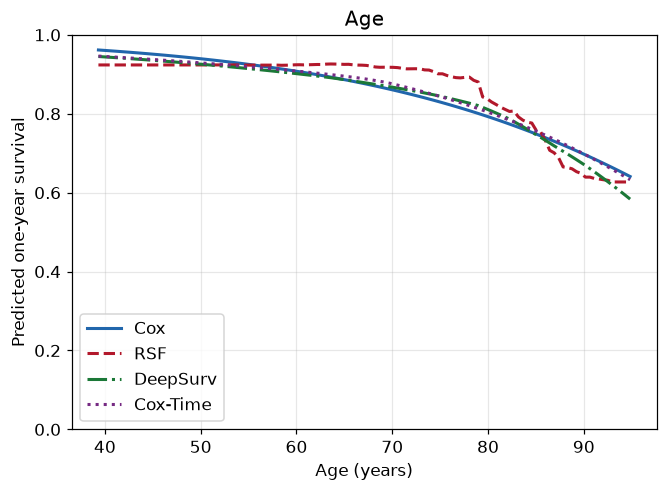

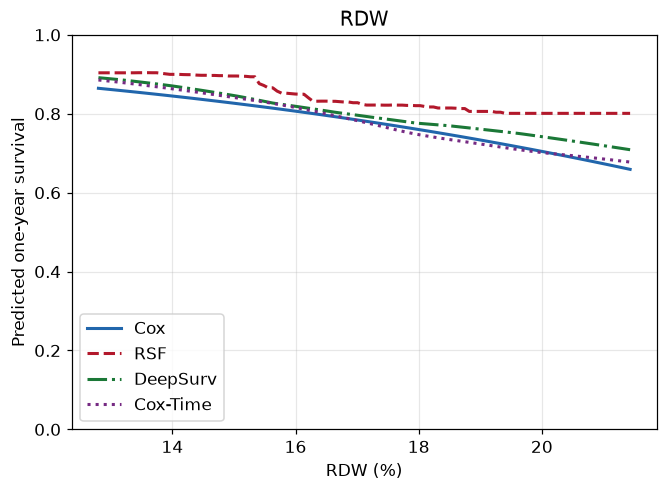

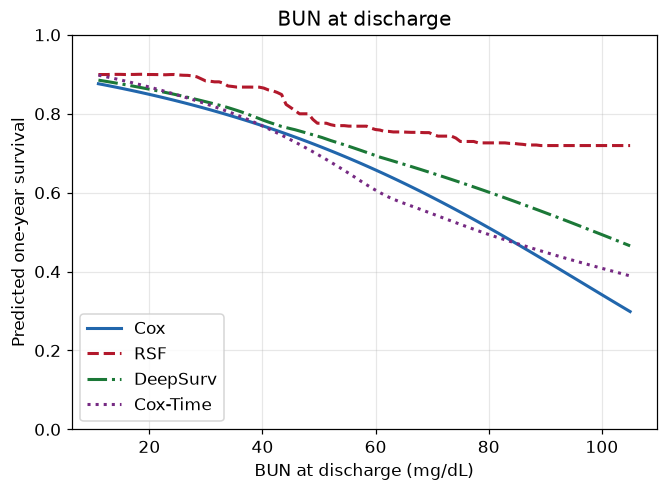

S at grid low  S at grid high  drop over grid  drop over IQR
covariate                model                                                                 
Age (years)              Cox               0.962           0.641           0.321          0.110
                         RSF               0.924           0.627           0.297          0.118
                         DeepSurv          0.945           0.584           0.361          0.105
                         Cox-Time          0.946           0.633           0.313          0.114
RDW (%)                  Cox               0.864           0.659           0.205          0.034
                         RSF               0.904           0.801           0.103          0.057
                         DeepSurv          0.891           0.709           0.183          0.044
                         Cox-Time          0.885           0.677           0.208          0.043
BUN at discharge (mg/dL) Cox               0.876           0.298           0.577          0.064
                         RSF               0.899           0.719           0.180          0.032
                         DeepSurv          0.885           0.465           0.420          0.061
                         Cox-Time          0.898           0.389           0.509          0.078

In [23]:
MODEL_STYLE = {
    "Cox": ("#2166ac", "-"),
    "RSF": ("#b2182b", "--"),
    "DeepSurv": ("#1b7837", "-."),
    "Cox-Time": ("#762a83", ":"),
}

FIG7_FILES = {"age_YEARS": "fig7a_age.png", "RDW": "fig7b_rdw.png",
              "BUN_discharge": "fig7c_bun_discharge.png"}


def grid_frame(covariate, values):
    # representative_row stores the comorbidity level as plain text; design_matrix needs the
    # categorical dtype back so get_dummies reproduces the two training-time columns
    rows = pd.concat([base_train.assign(**{covariate: v}) for v in values], ignore_index=True)
    rows[CAT_COL] = pd.Categorical(rows[CAT_COL], categories=train_df[CAT_COL].cat.categories)
    return rows


curve_rows = []
for covariate, label in PLOT_COVARIATES.items():
    grid = plot_grids[covariate]
    q1, q3 = train_df[covariate].quantile([0.25, 0.75])
    rows = grid_frame(covariate, np.concatenate([grid, [q1, q3]]))

    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    for name, (color, style) in MODEL_STYLE.items():
        pred = one_year_survival(name, rows)
        curve, (s_q1, s_q3) = pred[:len(grid)], pred[len(grid):]
        ax.plot(grid, curve, color=color, linestyle=style, linewidth=2, label=name)
        curve_rows.append([label, name, curve[0], curve[-1], curve[0] - curve[-1], s_q1 - s_q3])
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, FIG7_FILES[covariate]))
    plt.show()

model_curves = pd.DataFrame(curve_rows, columns=[
    "covariate", "model", "S at grid low", "S at grid high", "drop over grid", "drop over IQR"
]).set_index(["covariate", "model"]).round(3)
model_curves.to_csv(os.path.join(TAB_DIR, "table9_model_curve_ranges.csv"))
model_curves


**Figures 7a-7c**. The Cox rows of Table 9 reproduce Table 7 exactly, which confirms that all four models are drawn on the same grids and the same representative patient.

Over the interquartile range the four models agree. Age moves predicted one-year survival by 0.10 to 0.12 depending on the model, discharge BUN by 0.03 to 0.08 and RDW by 0.03 to 0.06, and all four put age first. Only the forest reorders the other two, ranking RDW above discharge BUN.

The models part company in the tails, and discharge BUN is the clearest case: across the plotted range Cox falls to 0.298, while Cox-Time ends at 0.389, DeepSurv at 0.465 and the forest at 0.719. The Cox curve is the linear extrapolation of the log hazard, so it holds its slope wherever the grid goes; DeepSurv follows it to roughly 40 mg/dL and then bends upwards, Cox-Time instead runs a little below it from 40 to about 85 mg/dL before crossing back above, and the forest flattens completely above about 75 mg/dL, where only 141 of the 3,168 training patients sit. With a leaf size of 50 there is no split left to make in that region, so the plateau is the forest running out of data rather than evidence that risk stops rising. RDW repeats the pattern more mildly, and age is where the four agree best, separating only past 85 years.

So the flexible models do not find a nonlinearity that the Cox model misses in the region where patients actually are. Their disagreement is confined to the sparse tails, and at the far end of every grid all three finish above the linear extrapolation.

---
# 9. Test-set model comparison

The 793 test patients are used for the first time here. For each model $\hat S(12 \mid X)$ is the predicted one-year survival probability and $r = 1 - \hat S(12 \mid X)$ the predicted one-year risk. The models are compared on discrimination (9.1), calibration (9.2) and prediction accuracy (9.3), then summarised in 9.4.


In [24]:
test_curves = {name: fn(test_df) for name, fn in SURVIVAL_CURVES.items()}
test_surv = pd.DataFrame(
    {name: surv_at_times(curves, np.array([HORIZON])).ravel() for name, curves in test_curves.items()},
    index=test_df.index)
test_risk = 1.0 - test_surv

print(f"Test set: {len(test_df)} patients, {int(test_df[EVENT_COL].sum())} events")
test_surv.describe().round(3)

Test set: 793 patients, 336 events


,Cox,RSF,DeepSurv,Cox-Time
count,793.000,793.000,793.000,793.000
mean,0.748,0.751,0.744,0.744
std,0.161,0.118,0.157,0.141
min,0.000,0.441,0.002,0.106
25%,0.668,0.655,0.657,0.655
50%,0.785,0.766,0.779,0.771
75%,0.868,0.855,0.864,0.860
max,0.986,0.942,0.968,0.965


The four models predict almost the same average one-year survival on the test set but not the same spread. The forest is the most compressed and never predicts below 0.44, while Cox has the widest spread and sends two patients essentially to zero. DeepSurv reaches 0.002 at its own minimum; Cox-Time stops at 0.106.

Both are the tails of Figures 7a-7c seen from the other side: the forest cannot leave the range its leaves cover, and the Cox linear predictor extrapolates without limit. The two near-zero Cox predictions belong to patients with discharge BUN of 137 and 236 mg/dL, the second beyond the training maximum of 199.7.


## 9.1 Discrimination

Uno's time-dependent C-index at $\tau$ = 12 months, ranking patients by the predicted one-year risk. `concordance_index_ipcw` needs the training survival object as well as the test one, since the censoring weights are estimated on the training data.


In [25]:
from sksurv.metrics import concordance_index_ipcw

y_train_surv, y_test_surv = surv_target(train_df), surv_target(test_df)

uno_c = {
    name: concordance_index_ipcw(y_train_surv, y_test_surv, test_risk[name].to_numpy(), tau=HORIZON)[0]
    for name in SURVIVAL_CURVES
}
pd.Series(uno_c, name="Uno's C (tau = 12 months)").round(4)

Cox         0.6959
RSF         0.6805
DeepSurv    0.6909
Cox-Time    0.6967
Name: Uno's C (tau = 12 months), dtype: float64

Uno's C separates the four models by 0.016: Cox-Time 0.697, Cox 0.696, DeepSurv 0.691, RSF 0.681. At $\tau$ = 12 months the index rests on the 199 test patients who die within the first year, so a gap this small is well inside what this test set can resolve and the ordering should not be read as a ranking. Cox-Time's lead over Cox is 0.0008, twenty times smaller again, so what the numbers support is the weaker statement that Cox, Cox-Time and DeepSurv discriminate equally well and only the forest is behind.

## 9.2 Calibration

Test patients are split into ten deciles of predicted one-year survival, separately for each model. Within each decile the observed one-year survival is the Kaplan-Meier estimate at 12 months rather than a raw proportion, since some patients in every decile are censored before then. A well-calibrated model has its points on the diagonal.


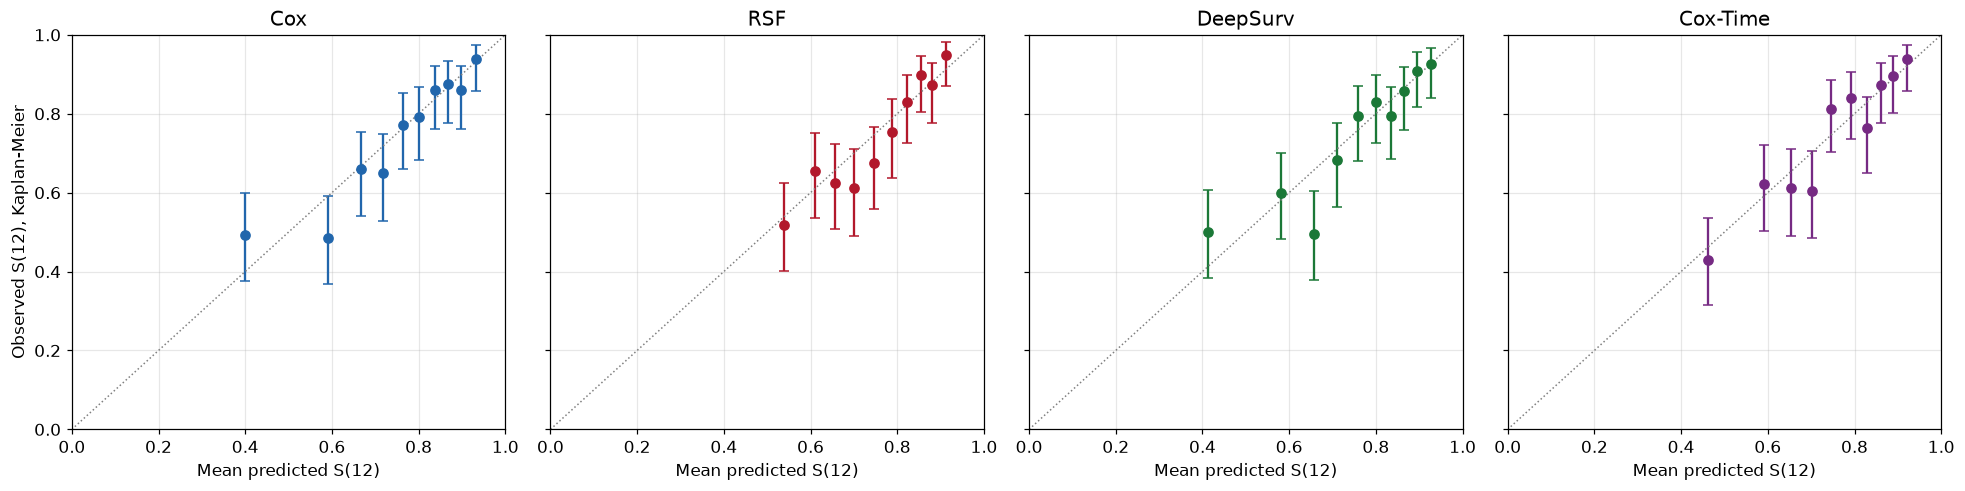

In [26]:
def calibration_table(name):
    decile = pd.qcut(test_surv[name], 10, labels=False, duplicates="drop")
    rows = []
    for g, idx in test_surv.groupby(decile).groups.items():
        sub = test_df.loc[idx]
        km = KaplanMeierFitter().fit(sub[TIME_COL], sub[EVENT_COL])
        ci = km.confidence_interval_survival_function_
        lo, hi = ci.loc[ci.index <= HORIZON].iloc[-1]
        rows.append({
            "decile": int(g) + 1, "n": len(sub),
            "predicted": test_surv.loc[idx, name].mean(),
            "observed": float(km.survival_function_at_times([HORIZON]).iloc[0]),
            "lower": lo, "upper": hi,
        })
    return pd.DataFrame(rows).set_index("decile")


calibration = {name: calibration_table(name) for name in SURVIVAL_CURVES}

fig, axes = plt.subplots(1, 4, figsize=(18.0, 4.6), sharex=True, sharey=True)
for ax, (name, (color, _)) in zip(axes, MODEL_STYLE.items()):
    tab = calibration[name]
    ax.errorbar(tab["predicted"], tab["observed"],
                yerr=[tab["observed"] - tab["lower"], tab["upper"] - tab["observed"]],
                fmt="o", color=color, capsize=3)
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1)
    ax.set_xlabel("Mean predicted S(12)")
    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Observed S(12), Kaplan-Meier")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig8_calibration.png"))
plt.show()

pd.concat(calibration, names=["model"]).round(3).to_csv(os.path.join(TAB_DIR, "table10_calibration.csv"))

**Figure 8 and Table 10**. Each decile holds about 80 patients, so the Kaplan-Meier intervals are roughly 0.2 wide and a single point off the diagonal is weak evidence by itself.

Cox is the best calibrated of the four, though it misses at its bottom end: it predicts 0.400 and 0.591 for its two lowest deciles against 0.492 and 0.485 observed, separating two groups that the test data does not separate at all. DeepSurv has the single largest miss in the figure, predicting 0.657 for its third decile against 0.496 observed. Cox-Time scatters around the diagonal rather than missing at one point, its fourth decile 0.098 too optimistic, its fifth 0.065 too pessimistic and its seventh 0.066 too optimistic, which is what leaves it last on the summary measure in Table 11 without any single catastrophic decile.

The forest is no longer the worst on that summary measure, but it is the one that misses in a structured way rather than at isolated points. Its decile means span only 0.538 to 0.912 against 0.400 to 0.933 for Cox, and that compression shows at both ends: the middle deciles sit below the diagonal, predicting 0.700 against 0.611 observed and 0.747 against 0.675, while the healthiest decile sits above it, 0.912 predicted against 0.950 observed.

## 9.3 Prediction accuracy

The integrated Brier score over the first year integrates the IPCW Brier score by the trapezoidal rule over the monthly points $t = 1, \dots, 12$ together with $\widehat{BS}(0) = 0$, which holds exactly since every patient is alive at discharge and every model predicts $S(0) = 1$:

$IBS = \frac{1}{12}\int_0^{12} \widehat{BS}(t)\,dt$

The censoring weights come from the training set, as for the discrimination measure.


In [27]:
monthly_bs = {}
for name, curves in test_curves.items():
    _, bs = brier_score(y_train_surv, y_test_surv, surv_at_times(curves, EVAL_TIMES), EVAL_TIMES)
    monthly_bs[name] = bs
monthly_bs = pd.DataFrame(monthly_bs, index=EVAL_TIMES.astype(int)).rename_axis("month")

ibs = monthly_bs.apply(lambda col: integrated_bs(col.to_numpy()))
ibs.rename("IBS").round(4)

Cox         0.1150
RSF         0.1169
DeepSurv    0.1153
Cox-Time    0.1142
Name: IBS, dtype: float64

The four values span 0.0027: Cox-Time lowest at 0.1142, then Cox at 0.1150 and DeepSurv at 0.1153, with the forest last at 0.1169. On prediction error over the first year the models are effectively tied, with the forest marginally behind.

## 9.4 Summary

Table 11 collects Uno's C, the integrated Brier score and one calibration number per model: the mean absolute gap between predicted and observed one-year survival across the ten deciles, weighted by decile size.


In [28]:
def mean_calibration_gap(tab):
    return np.average((tab["observed"] - tab["predicted"]).abs(), weights=tab["n"])

test_summary = pd.DataFrame({
    "Uno's C (tau=12)": pd.Series(uno_c),
    "IBS": ibs,
    "mean |observed - predicted|": pd.Series(
        {name: mean_calibration_gap(tab) for name, tab in calibration.items()}),
}).round(4)
test_summary.to_csv(os.path.join(TAB_DIR, "table11_test_summary.csv"))
test_summary

,Uno's C (tau=12),IBS,mean |observed - predicted|
Cox,0.6959,0.1150,0.0367
RSF,0.6805,0.1169,0.0385
DeepSurv,0.6909,0.1153,0.0420
Cox-Time,0.6967,0.1142,0.0422


**Table 11**. No model wins on all three measures. Cox-Time has the best C-index and the lowest IBS, 0.697 and 0.1142, and the worst calibration, a mean absolute gap of 0.042 across deciles. Cox is second on both of the first two, 0.696 and 0.1150, and the best calibrated at 0.037. The forest is last on discrimination and accuracy, 0.681 and 0.1169, and second on calibration at 0.039. Every margin here is small: 0.016 separates the best and worst C-index, 0.0027 the best and worst IBS, and 0.006 the best and worst calibration gap.

The picture matches the cross-validated search of Table 8, where the same models scored 0.110 to 0.112 on the training folds and the forest was also last. The test scores are slightly higher throughout, as expected once the models are scored on patients they never saw.

For RQ2 this says that relaxing the Cox assumptions did not measurably improve prediction here. DeepSurv drops linearity and additivity and matches the linear model without beating it. Cox-Time drops proportional hazards as well and finishes marginally ahead on discrimination and accuracy — by 0.0008 of C-index and 0.0008 of IBS — but with the worst calibration of the four, and Section 5 found the proportional hazards assumption adequate for this model, so there was little for a time-varying risk score to exploit in the first place. The forest, which assumes least, is last on both discrimination and accuracy.

This follows from Figures 7a-7c. The models make nearly the same predictions where the patients are, so they can hardly rank or score them differently, and the tails where they disagree hold too few patients to move a test-set average.


---
# 10. Additional analyses based on the research questions

Section 9 answered the three questions of Section 3 with the analyses the assignment required. This section takes each further: 10.1 collects the answer to RQ1, 10.2 checks two claims from Sections 8 and 9 that were only established in aggregate, and 10.3 runs the two interaction tests promised for RQ3.


## 10.1 Predictive accuracy at discharge (RQ1)

Sections 5 to 9 already answer RQ1. Discrimination on the test set is moderate at best: Uno's C at 12 months runs from 0.681 for the forest to 0.697 for Cox-Time, with Cox at 0.696 and DeepSurv at 0.691 (Table 11), a spread well inside what 199 one-year deaths can resolve. Prediction accuracy tells the same story, with the integrated Brier score running from 0.1142 to 0.1169. Calibration is adequate for all four, no model's mean absolute gap exceeding 0.042 across deciles, so the predictions are usable at the group level even where the ranking is weak.

The second half of RQ1 therefore has a qualified answer: no flexible model predicts one-year survival meaningfully better than the refitted Cox model on this test set. Cox-Time edges it on discrimination and accuracy, but by 0.0008 on each, and is the worst calibrated of the four; DeepSurv matches Cox without beating it; the forest is last on both discrimination and accuracy. Section 10.2 asks why, starting from the finding that the four models make nearly the same predictions where most patients sit.

## 10.2 Where the models differ, and whether it matters (RQ2)

RQ2 asked which of the Cox model's assumptions is responsible where the flexible models predict differently. Sections 8 and 9.4 answered in aggregate: the four models make nearly the same predictions where the patients are, and disagree only in the sparse tails, which hold too few patients to move a test-set average. This section checks both claims directly.


### 10.2.1 Do the four models rank the same patients as high-risk?

A shared Uno's C is consistent with the models agreeing on who is at risk, but also with different rankings that happen to score alike. The cell below checks this with the rank correlation between the four models' predicted one-year risk, the overlap of their top-risk patients, and Kaplan-Meier curves for the test set split into risk tertiles by the Cox model and by the forest.


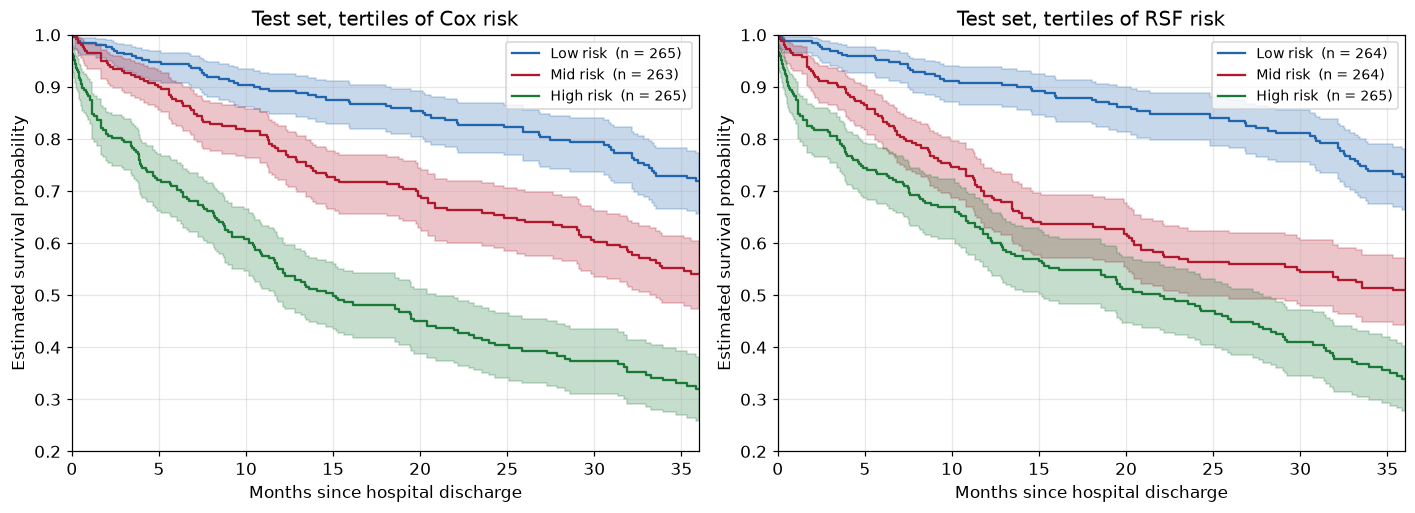

Top 20% of the test set by predicted risk: 159 patients per model

Spearman correlation of predicted one-year risk:
            Cox    RSF  DeepSurv  Cox-Time
Cox       1.000  0.884     0.976     0.976
RSF       0.884  1.000     0.911     0.908
DeepSurv  0.976  0.911     1.000     0.980
Cox-Time  0.976  0.908     0.980     1.000

Overlap of the top-risk sets:
 model A  model B  shared of top  shared %  Jaccard
     Cox      RSF            113    71.069    0.551
     Cox DeepSurv            141    88.679    0.797
     Cox Cox-Time            140    88.050    0.787
     RSF DeepSurv            124    77.987    0.639
     RSF Cox-Time            117    73.585    0.582
DeepSurv Cox-Time            138    86.792    0.767

Cox   S(12)|Low risk = 0.892  S(12)|Mid risk = 0.778  S(12)|High risk = 0.550
RSF   S(12)|Low risk = 0.908  S(12)|Mid risk = 0.691  S(12)|High risk = 0.618


In [29]:
spearman_corr = test_risk.corr(method="spearman").round(3)

TOP_FRAC = 0.20
n_top = int(round(TOP_FRAC * len(test_df)))
top_risk = {name: set(test_risk[name].nlargest(n_top).index) for name in test_risk.columns}

overlap_rows = []
model_names = list(test_risk.columns)
for i, a in enumerate(model_names):
    for b in model_names[i + 1:]:
        shared = len(top_risk[a] & top_risk[b])
        union = len(top_risk[a] | top_risk[b])
        overlap_rows.append({"model A": a, "model B": b, "shared of top": shared,
                             "shared %": 100 * shared / n_top, "Jaccard": shared / union})
risk_overlap = pd.DataFrame(overlap_rows).round(3)

spearman_corr.to_csv(os.path.join(TAB_DIR, "table12a_risk_correlation.csv"))
risk_overlap.to_csv(os.path.join(TAB_DIR, "table12b_risk_overlap.csv"))


def risk_tertile_groups(model_name):
    tertile = pd.qcut(test_risk[model_name], 3, labels=["Low risk", "Mid risk", "High risk"])
    return [(str(level), tertile == level) for level in ["Low risk", "Mid risk", "High risk"]]


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
s_cox_tert = plot_km_strata(axes[0], test_df, risk_tertile_groups("Cox"),
                            "Test set, tertiles of Cox risk", ylim=(0.2, 1.0))
s_rsf_tert = plot_km_strata(axes[1], test_df, risk_tertile_groups("RSF"),
                            "Test set, tertiles of RSF risk", ylim=(0.2, 1.0))
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig9_risk_tertiles.png"))
plt.show()

print(f"Top {TOP_FRAC:.0%} of the test set by predicted risk: {n_top} patients per model")
print()
print("Spearman correlation of predicted one-year risk:")
print(spearman_corr)
print()
print("Overlap of the top-risk sets:")
print(risk_overlap.to_string(index=False))
print()
for name, s in [("Cox", s_cox_tert), ("RSF", s_rsf_tert)]:
    print(f"{name:5s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))


**Table 12 and Figure 9**. The models mostly agree on who is at risk. Cox, DeepSurv and Cox-Time correlate at 0.976 or higher and share 87-89% of their own top-risk quintile; the forest is the outlier, correlating at 0.88-0.91 and sharing only 71-78%. For three of the four models the near-identical Uno's C in Table 11 therefore reflects genuine agreement on the ranking, while the forest ranks patients differently enough to matter.

Figure 9 shows what that costs. Tertiles of predicted Cox risk give one-year survival of 0.892, 0.778 and 0.550, with confidence bands that stay apart across the full follow-up. Tertiles of RSF risk separate the low tertile about as well (0.908) but compress the other two, 0.691 against 0.618, with bands that overlap for most of the follow-up. The forest's compressed prediction range is therefore not just a property of the marginal distribution of its predictions: patients it calls mid risk and patients it calls high risk turn out to have similar outcomes, where the Cox model separates the same two groups cleanly. That is the patient-level version of the discrimination gap in Table 11.


### 10.2.2 Performance in clinically meaningful subgroups

Section 9.4 argued that the tail disagreements are too rare to move a test-set average. This checks that by scoring the models inside the regions where Figures 7a-7c showed the widest disagreement instead of averaging over them: discharge BUN and age, split at their **training**-set medians so the subgroup definitions do not depend on the test data.


In [30]:
train_bun_median = train_df["BUN_discharge"].median()
train_age_median = train_df["age_YEARS"].median()

SUBGROUPS = {
    f"Discharge BUN <= {train_bun_median:.0f}": test_df["BUN_discharge"] <= train_bun_median,
    f"Discharge BUN > {train_bun_median:.0f}": test_df["BUN_discharge"] > train_bun_median,
    f"Age <= {train_age_median:.0f}": test_df["age_YEARS"] <= train_age_median,
    f"Age > {train_age_median:.0f}": test_df["age_YEARS"] > train_age_median,
}

subgroup_rows = []
for label, mask in SUBGROUPS.items():
    mask_pos = mask.to_numpy()
    sub_test_df = test_df[mask]
    sub_y_test = surv_target(sub_test_df)
    n_deaths_12 = int(((sub_test_df[EVENT_COL] == 1) & (sub_test_df[TIME_COL] <= HORIZON)).sum())
    for name, curves in test_curves.items():
        sub_curves = curves.loc[:, mask_pos]
        sub_risk = 1.0 - surv_at_times(sub_curves, np.array([HORIZON])).ravel()
        c_index = concordance_index_ipcw(y_train_surv, sub_y_test, sub_risk, tau=HORIZON)[0]
        _, bs = brier_score(y_train_surv, sub_y_test, surv_at_times(sub_curves, EVAL_TIMES), EVAL_TIMES)
        sub_ibs = integrated_bs(bs)
        subgroup_rows.append({"subgroup": label, "model": name, "n": int(mask.sum()),
                              "deaths by 12m": n_deaths_12,
                              "Uno's C": round(c_index, 4), "IBS": round(sub_ibs, 4)})

subgroup_performance = pd.DataFrame(subgroup_rows).set_index(["subgroup", "model"])
subgroup_performance.to_csv(os.path.join(TAB_DIR, "table13_subgroup_performance.csv"))
subgroup_performance


n  deaths by 12m  Uno's C     IBS
subgroup            model                                        
Discharge BUN <= 28 Cox       430             81   0.7140  0.0901
                    RSF       430             81   0.6946  0.0933
                    DeepSurv  430             81   0.7018  0.0910
                    Cox-Time  430             81   0.7079  0.0899
Discharge BUN > 28  Cox       363            118   0.6361  0.1446
                    RSF       363            118   0.6173  0.1449
                    DeepSurv  363            118   0.6346  0.1441
                    Cox-Time  363            118   0.6349  0.1431
Age <= 76           Cox       406             62   0.6663  0.0787
                    RSF       406             62   0.7010  0.0783
                    DeepSurv  406             62   0.6785  0.0786
                    Cox-Time  406             62   0.6815  0.0784
Age > 76            Cox       387            137   0.6172  0.1532
                    RSF       387            137   0.5800  0.1574
                    DeepSurv  387            137   0.6085  0.1538
                    Cox-Time  387            137   0.6203  0.1519

**Table 13**. Splitting by discharge BUN does not overturn Table 11's ranking on discrimination: in both the low- and high-BUN groups Cox has the best Uno's C (0.714 and 0.636) and the forest the worst (0.695 and 0.617). Prediction error is another matter. Cox-Time has the lowest IBS in both BUN groups, 0.0899 against Cox's 0.0901 and 0.1431 against 0.1446, and in fact in all four subgroups of the table, though every one of those margins is a fraction of what separates the four models overall.

Splitting by age does overturn the discrimination ranking. Among patients 76 and younger the forest has the best discrimination, 0.701 against Cox's 0.666; among patients over 76 Cox-Time is narrowly ahead at 0.620 with Cox at 0.617, and the forest is worst at 0.580. The two age subgroups divide the events very unevenly, only 62 of the 199 one-year deaths falling among the younger patients, so the forest's apparent edge there rests on the thinnest slice of events in the table and is the reading most likely to be noise.

Discharge BUN was the covariate that separated the models most in Figures 7a-7c, yet age produces the only reversal here. That fits Section 9's point about the BUN tail: the models disagreed at values reached by a small minority, so a two-way split at the median puts most of that disagreement in the same subgroup as everyone else and dilutes it.


## 10.3 The two pre-specified interactions (RQ3)

RQ3 is tested on the Cox model only. It asks whether one interaction between two named covariates improves on the additive model, and only a parametric model yields a term for that: a hazard ratio, a confidence interval, a p-value. The forest and the two networks absorb interactions implicitly inside a tree ensemble or a hidden layer, so there is nothing to pull out and test.

Sections 8 and 9 already gave the indirect answer, and it is what motivates asking the direct one: three models free to fit arbitrary interactions predicted no better than the additive Cox model. An explicit test turns that into a statement about two named interactions, both fixed in Section 3.2 before these results were seen. Two tests chosen in advance keep multiplicity to a footnote, so the reference level below is the Bonferroni-corrected 0.025.


In [31]:
from scipy.stats import chi2

FORMULA_INT_BUN = PA2_FORMULA + " + BUN_discharge:delta_BUN"
FORMULA_INT_AGE = PA2_FORMULA + " + age_YEARS:BUN_discharge"


def load_or_fit_cox(name, formula):
    path = os.path.join(MODEL_DIR, f"{name}.joblib")
    if os.path.exists(path):
        return joblib.load(path)
    model = CoxPHFitter().fit(train_df, duration_col=TIME_COL, event_col=EVENT_COL, formula=formula)
    joblib.dump(model, path)
    return model


cox_int_bun = load_or_fit_cox("cox_int_bun", FORMULA_INT_BUN)
cox_int_age = load_or_fit_cox("cox_int_age", FORMULA_INT_AGE)


def lrt_row(model, term):
    stat = 2 * (model.log_likelihood_ - cox_train.log_likelihood_)
    p = chi2.sf(stat, 1)
    hr = model.hazard_ratios_[term]
    ci_lo, ci_hi = model.summary.loc[term, ["exp(coef) lower 95%", "exp(coef) upper 95%"]]
    wald_p = model.summary.loc[term, "p"]
    return {"interaction term": term, "HR": hr, "lower 95%": ci_lo, "upper 95%": ci_hi,
            "Wald p": wald_p, "LR statistic": stat, "LR p": p,
            "concordance": model.concordance_index_}


BONFERRONI_ALPHA = 0.05 / 2
interaction_summary = pd.DataFrame([
    lrt_row(cox_int_bun, "BUN_discharge:delta_BUN"),
    lrt_row(cox_int_age, "age_YEARS:BUN_discharge"),
]).set_index("interaction term").round(4)
interaction_summary.to_csv(os.path.join(TAB_DIR, "table14a_interactions.csv"))

main_effects = ["age_YEARS", "BUN_discharge", "delta_BUN"]
main_effect_compare = pd.DataFrame({
    "HR (additive)": cox_train.hazard_ratios_[main_effects],
    "HR (+BUNxdBUN)": cox_int_bun.hazard_ratios_[main_effects],
    "HR (+agexBUN)": cox_int_age.hazard_ratios_[main_effects],
}).round(4)

print(f"cox_train (additive): log-likelihood = {cox_train.log_likelihood_:.2f}   "
      f"concordance = {cox_train.concordance_index_:.4f}")
print(f"Bonferroni threshold for 2 pre-specified tests: {BONFERRONI_ALPHA}")
print()
print("Main effects, additive model vs. each interaction model:")
print(main_effect_compare)
print()
interaction_summary


cox_train (additive): log-likelihood = -9990.34   concordance = 0.6995
Bonferroni threshold for 2 pre-specified tests: 0.025

Main effects, additive model vs. each interaction model:
               HR (additive)  HR (+BUNxdBUN)  HR (+agexBUN)
covariate                                                  
age_YEARS             1.0447          1.0443         1.0421
BUN_discharge         1.0238          1.0215         1.0180
delta_BUN             0.9900          0.9841         0.9900



,HR,lower 95%,upper 95%,Wald p,LR statistic,LR p,concordance
interaction term,,,,,,,
BUN_discharge:delta_BUN,1.0001,1.0000,1.0002,0.0124,5.8541,0.0155,0.6996
age_YEARS:BUN_discharge,1.0001,0.9998,1.0003,0.5921,0.2880,0.5915,0.6995


**Table 14a**. The `delta_BUN` x `BUN_discharge` interaction is significant at the pre-specified 0.025 threshold: the likelihood-ratio test gives 5.85 on 1 degree of freedom, p = 0.016, and the Wald test on the term agrees at p = 0.012. The `age_YEARS` x `BUN_discharge` interaction is not, at 0.29 and p = 0.59.

The BUN interaction's hazard ratio of 1.0001 looks negligible only because it multiplies a product that runs into the thousands; over the range the covariates actually take, the term moves the prediction by the amount Figure 10 shows. Adding it also shifts `delta_BUN`'s hazard ratio from 0.990 to 0.984, but with the covariates left uncentered a main effect is now conditional on the other interacting covariate being zero, so that is not a like-for-like comparison with Table 5. The age interaction leaves every main effect close to its additive value, consistent with a term that adds nothing.

Neither interaction moves training concordance beyond its third decimal. A structurally real interaction, confirmed by a test designed in advance to find it, need not be practically important for ranking patients; Table 14b checks whether it is.


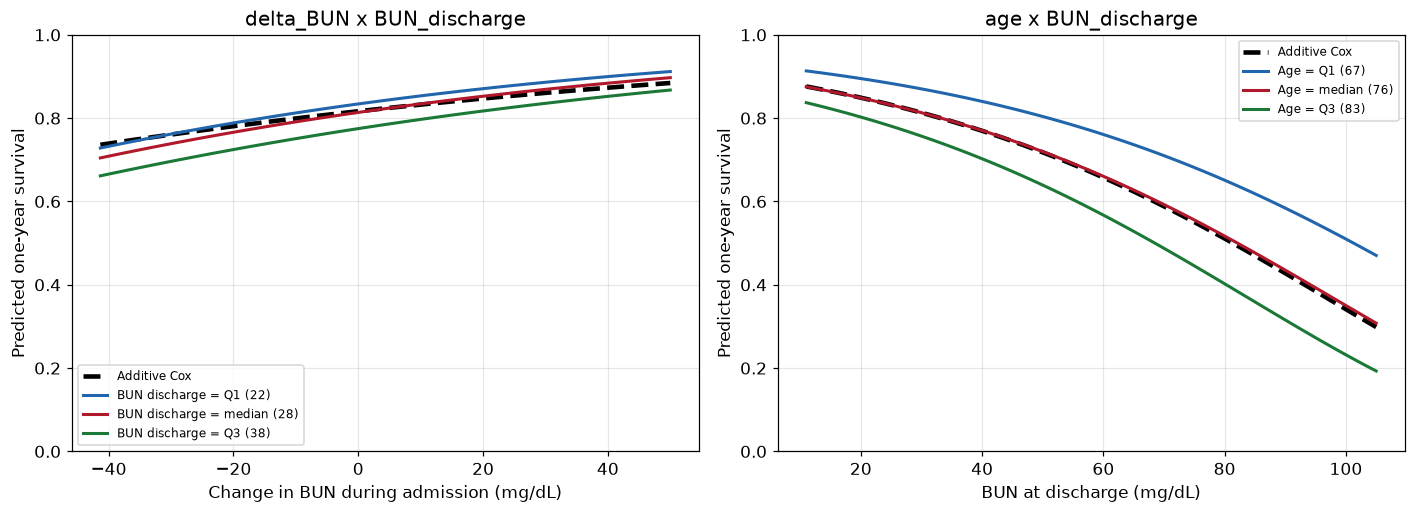

In [32]:
bun_q1, bun_med, bun_q3 = train_df["BUN_discharge"].quantile([0.25, 0.5, 0.75])
age_q1, age_med, age_q3 = train_df["age_YEARS"].quantile([0.25, 0.5, 0.75])

dbun_lo, dbun_hi = train_df["delta_BUN"].quantile([0.01, 0.99])
dbun_grid = np.linspace(dbun_lo, dbun_hi, 120)
bun_grid = plot_grids["BUN_discharge"]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax = axes[0]
ax.plot(dbun_grid, one_year_curve(cox_train, "delta_BUN", dbun_grid, base_train),
        color="black", linestyle="--", linewidth=3, label="Additive Cox")
for level, value, color in zip(["Q1", "median", "Q3"], [bun_q1, bun_med, bun_q3], PALETTE):
    base = base_train.assign(BUN_discharge=value)
    ax.plot(dbun_grid, one_year_curve(cox_int_bun, "delta_BUN", dbun_grid, base),
            color=color, linewidth=2, label=f"BUN discharge = {level} ({value:.0f})")
ax.set_xlabel("Change in BUN during admission (mg/dL)")
ax.set_ylabel("Predicted one-year survival")
ax.set_title("delta_BUN x BUN_discharge")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(bun_grid, one_year_curve(cox_train, "BUN_discharge", bun_grid, base_train),
        color="black", linestyle="--", linewidth=3, label="Additive Cox")
for level, value, color in zip(["Q1", "median", "Q3"], [age_q1, age_med, age_q3], PALETTE):
    base = base_train.assign(age_YEARS=value)
    ax.plot(bun_grid, one_year_curve(cox_int_age, "BUN_discharge", bun_grid, base),
            color=color, linewidth=2, label=f"Age = {level} ({value:.0f})")
ax.set_xlabel("BUN at discharge (mg/dL)")
ax.set_ylabel("Predicted one-year survival")
ax.set_title("age x BUN_discharge")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig10_interactions.png"))
plt.show()


**Figure 10**. The left panel shows why the BUN interaction is significant: the three curves are not parallel. Where BUN fell during the stay, the discharge level spreads the predictions by 0.067; where it rose, the same three levels span only 0.045. The effect of the change therefore depends on the level reached, separating patients more when the change was a fall — the reading Section 3.2 anticipated, and the one Section 5.1 gives in terms of the admission level. The black additive line does not coincide with the median-BUN curve even though both hold `BUN_discharge` at the same value, because the two come from differently fitted models; that separation is itself a trace of the interaction changing `delta_BUN`'s estimated effect.

The right panel shows why the age interaction is not: the three age curves stay close to parallel with the additive line across the full BUN range. The gap between the youngest and oldest does widen at high BUN, but that is expected of a purely additive proportional-hazards model once a linear log hazard is turned into a bounded probability, since differences compress near S = 1 and stretch through the middle of the range whether or not an interaction is present. The likelihood-ratio test is what tells the two apart, and it finds nothing beyond that expected non-parallelism.


In [33]:
def fit_int_fold(formula, d_fit, d_val):
    model = CoxPHFitter().fit(d_fit, duration_col=TIME_COL, event_col=EVENT_COL, formula=formula)
    return model.predict_survival_function(d_val), np.nan


int_bun_results = cv_search(lambda p, a, b: fit_int_fold(FORMULA_INT_BUN, a, b), [{}])
int_age_results = cv_search(lambda p, a, b: fit_int_fold(FORMULA_INT_AGE, a, b), [{}])


def test_scores(model):
    curves = model.predict_survival_function(test_df)
    risk = 1.0 - surv_at_times(curves, np.array([HORIZON])).ravel()
    c_index = concordance_index_ipcw(y_train_surv, y_test_surv, risk, tau=HORIZON)[0]
    _, bs = brier_score(y_train_surv, y_test_surv, surv_at_times(curves, EVAL_TIMES), EVAL_TIMES)
    ibs = integrated_bs(bs)
    return c_index, ibs


interaction_performance = pd.DataFrame([
    {"model": "Cox (additive)",
     **dict(zip(["Uno's C (test)", "IBS (test)"], test_scores(cox_train))),
     "CV IBS": cox_results.iloc[0]["IBS"], "CV IBS SE": cox_results.iloc[0]["IBS_SE"]},
    {"model": "+ BUN_discharge x delta_BUN",
     **dict(zip(["Uno's C (test)", "IBS (test)"], test_scores(cox_int_bun))),
     "CV IBS": int_bun_results.iloc[0]["IBS"], "CV IBS SE": int_bun_results.iloc[0]["IBS_SE"]},
    {"model": "+ age_YEARS x BUN_discharge",
     **dict(zip(["Uno's C (test)", "IBS (test)"], test_scores(cox_int_age))),
     "CV IBS": int_age_results.iloc[0]["IBS"], "CV IBS SE": int_age_results.iloc[0]["IBS_SE"]},
]).set_index("model").round(4)
interaction_performance.to_csv(os.path.join(TAB_DIR, "table14b_interaction_performance.csv"))
interaction_performance

,Uno's C (test),IBS (test),CV IBS,CV IBS SE
model,,,,
Cox (additive),0.6959,0.1150,0.1097,0.003
+ BUN_discharge x delta_BUN,0.6933,0.1152,0.1094,0.003
+ age_YEARS x BUN_discharge,0.6955,0.1151,0.1097,0.003


**Table 14b**. Despite the significant likelihood-ratio test, the BUN interaction does not improve prediction on the test set: Uno's C drops slightly, from 0.696 to 0.693, and the test IBS is unchanged to three decimals (0.1150 to 0.1152). The cross-validated IBS moves the other way, 0.1097 to 0.1094, but by a small fraction of the fold-to-fold standard error (0.0030). The age interaction, consistent with its null test, leaves every column essentially unchanged.

This answers RQ3. The pre-specified test finds a real, if small, interaction between the change in BUN and the discharge level: the effect of BUN improving or worsening during the stay genuinely depends on where the patient ends up. But that structure was already available to the flexible models of Section 7, which gained nothing from it. The interaction is a fact about the hazard, not a lever that moves one-year prediction on these patients. The age interaction is neither real nor useful: the two strongest predictors act on survival independently of each other.


---
# 11. Final discussion

Seven terms carry the model on the training data (Table 5): age, discharge BUN, RDW, BNP and length of stay raise the hazard, while sodium and `delta_BUN` lower it. `delta_BUN` is the admission level read backwards, so of two patients leaving with the same BUN the one who started higher does worse. Sex, comorbidity burden, white blood cells, platelets, discharge creatinine and discharge GFR are not associated with survival in any fit. Over the range patients actually occupy age separates predictions most, moving predicted one-year survival by 0.11 across its interquartile range against 0.06 for discharge BUN and 0.03 for RDW (Table 7); discharge BUN dominates the plotted range only because of its long right tail.

The Cox conclusions were stable under the training fit. No hazard ratio moved by more than 2.2%, every full-data estimate fell inside the training confidence interval, and only bilirubin and potassium lost significance — both marginal to begin with, and moving because the intervals widened on 20% less data rather than because the effects changed (Table 5). The proportional hazards flags did move, with no covariate flagged on both the full and the training data (Table 6), but the two fits share most of their patients, so flags that swap like this are noise. No p-value in either fit falls below 0.021 and the Schoenfeld smoothers are flat throughout (Figure 5), so the assumption remains an adequate approximation, as PA2 concluded.

The flexible models found no nonlinearity that the Cox model misses where the patients are. Over the interquartile ranges of age, RDW and discharge BUN the four models move predicted survival by similar amounts and all put age first (Table 9), and Cox, DeepSurv and Cox-Time rank individual test patients almost identically, correlating at 0.98 and sharing 87-89% of their top-risk quintile (Table 12). They part company only in the sparse tails, where the forest flattens and the networks end above the Cox extrapolation — models running out of data rather than evidence of curvature. The forest is the one that ranks patients differently (0.88-0.91), and that costs it: its risk tertiles separate mid from high risk by 0.07 in one-year survival where the Cox tertiles separate the same two groups by 0.23 (Figure 9).

No model is clearly best on the test set. Cox-Time has both the highest Uno's C (0.697, against 0.696, 0.691 and 0.681) and the lowest integrated Brier score (0.1142 against 0.1150, 0.1153 and 0.1169), and the worst calibration (a mean absolute gap of 0.042 across deciles, against 0.037 for Cox, 0.039 for the forest and 0.042 for DeepSurv; Table 11). Every one of those margins is smaller than what 199 one-year deaths among 793 test patients can resolve, Cox-Time leading Cox by 0.0008 on each of the first two, so the defensible reading is not a ranking: no flexible model beats the Cox model by a margin this test set can detect, all four are adequately calibrated at the group level, and the forest is the one consistently behind, last on discrimination and accuracy and worst on discrimination in three of the four subgroups of Table 13.

The models therefore give the same answers to RQ1 and RQ2. One-year prediction from discharge information sits at a C of about 0.69, and relaxing linearity and additivity (DeepSurv), proportional hazards as well (Cox-Time) or all three (the forest) buys no discrimination or accuracy this test set can detect; the two networks are also the worst calibrated of the four. RQ3 is the only question where model choice matters, and even there the two approaches agree: the pre-specified `delta_BUN` by `BUN_discharge` interaction is real (LR 5.85 on 1 df, p = 0.016) but leaves test-set performance untouched (Table 14b), which is the explicit version of what the flexible models said implicitly by gaining nothing from being free to fit it. The age interaction is null on both readings.

Four limitations. The data is synthetic, so the associations describe the generating process of dataset 2 rather than a clinical population. The evaluation rests on a single 80/20 split with one seed, and since the differences in Table 11 are smaller than one test set of this size can resolve, another seed could reorder them; a repeated split or nested cross-validation would give an interval around each number instead of a point. The covariate set was chosen in PA2 on the full dataset, so the patients later used as the test set contributed to selecting the model evaluated on them, which makes all four test scores mildly optimistic. Finally, the models see only what is recorded at discharge, with no medications, ejection fraction or post-discharge information, and the outcome is all-cause death with censoring assumed independent of survival given the covariates; a C of 0.69 is what that information supports, and no change of model raised it.
